<a href="https://colab.research.google.com/github/ilimkka/DiplomaWork2026Ilim/blob/main/DiplomaWorkMain_Ilim.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Part 1: Data Loading and Initial Preparation**

---



Previously, Data was partially prepared on WorldBank DataBank platform and in Excel. All dataset versions will be provided by request / in repository.

Loading & Previewing: We import pandas, load the Kyrgyz Republic CSV data into a DataFrame (df), and use df.head() to verify the data loaded correctly by inspecting the first five rows.

Structure Check: We then use df.info() to get a concise summary of the dataset's structure—including row/column counts, data types, and non-null values - to identify any missing data before beginning our analysis.

In [ ]:
import pandas as pd

df = pd.read_csv('/content/DatasetKGFeb - countryIndicatorDataTable-Kyrgyz Republic.csv')
print("CSV file loaded successfully into a DataFrame named 'df'. Displaying the first 5 rows:")
df.head()

CSV file loaded successfully into a DataFrame named 'df'. Displaying the first 5 rows:


,Indicator Name,2000,2001,2002,2003,2004,2005,2006,2007,2008,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024\n
0,"Unemployment, total (% of total labor force) (...",7.54,7.84,12.55,9.92,8.53,8.11,8.27,8.10,8.22,...,4.20,4.01,3.32,4.56,5.45,5.95,5.15,4.77,3.50,--\n
1,"Exchange Rates, US Dollar per Domestic Currency",0.02,0.02,0.02,0.02,0.02,0.02,0.03,0.03,0.03,...,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,--\n
2,Employment in agriculture (% of total employme...,53.07%,52.92%,49.10%,43.24%,38.91%,38.50%,36.27%,34.48%,34.01%,...,30.45%,29.41%,27.87%,27.69%,24.21%,25.11%,25.17%,24.60%,23.85%,--\n
3,"Foreign direct investment, net inflows (% of GDP)",-0.17,0.33,0.29,2.37,7.93,1.73,6.42,5.47,7.33,...,17.13,9.09,-1.39,1.74,4.31,-4.85,2.45,0.45,1.05,4.04\n
4,"Inflation, GDP deflator (annual % growth)",27.16,7.33,2.03,3.97,5.11,7.13,9.39,14.88,22.22,...,3.43,6.05,6.33,3.45,9.81,5.34,15.99,19.66,19.86,4.74\n


In [ ]:
print("First 5 rows of the DataFrame:")
df.head()

print("\nDataFrame Information:")
df.info()

First 5 rows of the DataFrame:

DataFrame Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Indicator Name  10 non-null     object
 1   2000            10 non-null     object
 2   2001            10 non-null     object
 3   2002            10 non-null     object
 4   2003            10 non-null     object
 5   2004            10 non-null     object
 6   2005            10 non-null     object
 7   2006            10 non-null     object
 8   2007            10 non-null     object
 9   2008            10 non-null     object
 10  2009            10 non-null     object
 11  2010            10 non-null     object
 12  2011            10 non-null     object
 13  2012            10 non-null     object
 14  2013            10 non-null     object
 15  2014            10 non-null     object
 16  2015            10 non-null     object
 17  20

To summarize the loaded data, I will first identify the year columns, clean them by removing non-numeric characters and placeholders, convert them to a numeric data type, and then calculate descriptive statistics for these numeric columns.



In [ ]:
import numpy as np

# 1. Identify all year columns (from '2000' to '2024')
year_columns = [str(year) for year in range(2000, 2025)]

# Ensure only existing columns are selected
year_columns = [col for col in year_columns if col in df.columns]

# Make a copy to avoid SettingWithCopyWarning and preserve original data if needed
df_cleaned = df.copy()

# 2. For each identified year column, clean the data
#    by replacing the '%' character and any '--' string with NaN.
for col in year_columns:
    # Replace '%' character and convert to string first to handle potential non-string types
    df_cleaned[col] = df_cleaned[col].astype(str).str.replace('%', '', regex=False)
    # Replace '--' with NaN
    df_cleaned[col] = df_cleaned[col].replace('--', np.nan)

# 3. Convert these cleaned year columns to a numeric data type,
#    coercing any remaining non-numeric values to NaN.
for col in year_columns:
    df_cleaned[col] = pd.to_numeric(df_cleaned[col], errors='coerce')

print("Descriptive statistics for numeric year columns:")
# 4. Display the descriptive statistics for all numeric columns in the DataFrame
#    using the .describe() method.
df_cleaned[year_columns].describe()

Descriptive statistics for numeric year columns:


,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
count,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,...,9.000000,9.000000,9.00000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000
mean,617.250000,612.393333,563.252222,567.783333,424.738889,742.501111,512.368889,667.421111,662.785556,615.081111,...,1109.422222,871.153333,1139.87000,715.412222,966.656667,1382.646667,285.521111,742.905556,833.810000,2037.766667
std,1703.842157,1694.822764,1537.571560,1529.422299,1087.428900,2027.425408,1281.246343,1708.584157,1638.685409,1477.986885,...,2853.184369,2174.730725,2942.75638,1690.485336,2431.532176,3623.793417,611.145813,1627.557038,1881.633865,5377.662073
min,-0.170000,0.020000,-0.020000,0.020000,0.020000,-0.180000,0.030000,0.030000,0.030000,0.020000,...,0.020000,0.010000,0.01000,-1.390000,0.010000,0.010000,-7.150000,0.010000,0.010000,0.010000
25%,5.440000,5.320000,0.290000,3.970000,7.030000,1.730000,6.420000,8.100000,8.220000,4.040000,...,4.590000,3.880000,4.34000,3.320000,3.450000,4.600000,0.010000,5.150000,4.770000,3.500000
50%,27.160000,7.840000,12.550000,9.920000,8.530000,8.110000,9.390000,14.880000,22.220000,8.410000,...,8.420000,17.130000,9.09000,6.330000,4.560000,9.810000,5.950000,15.990000,19.660000,19.860000
75%,53.070000,52.920000,49.100000,43.240000,39.110000,40.620000,41.640000,41.450000,45.580000,43.430000,...,46.360000,46.550000,44.59000,41.580000,39.570000,40.830000,45.330000,51.620000,54.220000,53.590000
max,5155.000000,5126.000000,4655.000000,4634.000000,3303.000000,6135.000000,3887.000000,5182.000000,4967.000000,4464.000000,...,8640.000000,6583.000000,8911.00000,5084.000000,7356.000000,10970.000000,1794.950000,4791.000000,5601.000000,16276.000000


To analyze the unique indicators, I will print the unique values from the 'Indicator Name' column of the `df_cleaned` DataFrame.



In [ ]:
print("Unique Indicator Names:")
print(df_cleaned['Indicator Name'].unique())

Unique Indicator Names:
['Unemployment, total (% of total labor force) (national estimate)'
 'Exchange Rates, US Dollar per Domestic Currency'
 'Employment in agriculture (% of total employment) (modeled ILO estimate)'
 'Foreign direct investment, net inflows (% of GDP)'
 'Inflation, GDP deflator (annual % growth)'
 'School enrollment, tertiary (% gross)'
 'Personal remittances, received (current US$)' 'GDP (annual % growth)'
 'Kumtor gold production (thousand of tonnes by year)' 'Gold prices (US$)']


In [ ]:
df_cleaned

,Indicator Name,2000,2001,2002,2003,2004,2005,2006,2007,2008,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024\n
0,"Unemployment, total (% of total labor force) (...",7.54,7.84,12.55,9.92,8.53,8.11,8.27,8.10,8.22,...,4.20,4.01,3.32,4.56,5.45,5.95,5.15,4.77,3.50,--\n
1,"Exchange Rates, US Dollar per Domestic Currency",0.02,0.02,0.02,0.02,0.02,0.02,0.03,0.03,0.03,...,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,--\n
2,Employment in agriculture (% of total employme...,53.07,52.92,49.10,43.24,38.91,38.50,36.27,34.48,34.01,...,30.45,29.41,27.87,27.69,24.21,25.11,25.17,24.60,23.85,--\n
3,"Foreign direct investment, net inflows (% of GDP)",-0.17,0.33,0.29,2.37,7.93,1.73,6.42,5.47,7.33,...,17.13,9.09,-1.39,1.74,4.31,-4.85,2.45,0.45,1.05,4.04\n
4,"Inflation, GDP deflator (annual % growth)",27.16,7.33,2.03,3.97,5.11,7.13,9.39,14.88,22.22,...,3.43,6.05,6.33,3.45,9.81,5.34,15.99,19.66,19.86,4.74\n
5,"School enrollment, tertiary (% gross)",33.69,39.27,42.23,39.49,39.11,40.62,41.64,41.45,45.58,...,46.55,44.59,41.58,39.57,40.83,45.33,51.62,54.22,53.59,--\n
6,"Personal remittances, received (current US$)",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,$3.1b\n
7,GDP (annual % growth),5.44,5.32,-0.02,7.03,7.03,-0.18,3.10,8.54,8.40,...,3.88,4.34,4.74,3.76,4.60,-7.15,5.51,8.97,9.01,9.04
8,Kumtor gold production (thousand of tonnes by ...,5155.00,5126.00,4655.00,4634.00,3303.00,6135.00,3887.00,5182.00,4967.00,...,6583.00,8911.00,5084.00,7356.00,10970.00,705.00,4791.00,5601.00,16276.00,7286
9,Gold prices (US$),273.50,272.51,308.07,370.01,413.01,451.58,619.20,711.84,872.28,...,1151.73,1250.33,1272.25,1263.13,1384.60,1794.95,1789.25,1790.61,1953.03,2356.91


I will define the `remittances_millions_usd` list, locate the 'Personal remittances, received (current US$)' row in `df_cleaned`, update the year columns with the new data, and convert these columns to a numeric data type to correctly represent the remittances data.



In [ ]:
remittances_millions_usd = [
    2.24, 4.53, 30.29, 70.33, 179.06,
    313.25, 473.07, 704.00, 1220.00, 981.96,
    1270.00, 1710.00, 2030.00, 2280.00, 2240.00,
    1690.00, 1990.00, 2490.00, 2690.00, 2700.00,
    2630.00, 3010.00, 3230.00, 2850.00, 3100.00
]

# Clean column names by stripping whitespace, including newlines
df_cleaned.columns = df_cleaned.columns.str.strip()

# Re-identify all year columns (from '2000' to '2024') after cleaning column names
year_columns = [str(year) for year in range(2000, 2025)]
year_columns = [col for col in year_columns if col in df_cleaned.columns]

# Find the index of the row for 'Personal remittances, received (current US$)'
remittances_row_index = df_cleaned[df_cleaned['Indicator Name'] == 'Personal remittances, received (current US$)'].index[0]

# Update the values in the year columns for this specific indicator
df_cleaned.loc[remittances_row_index, year_columns] = remittances_millions_usd

# Convert the updated year columns to a numeric data type, coercing any non-numeric values to NaN
for col in year_columns:
    df_cleaned[col] = pd.to_numeric(df_cleaned[col], errors='coerce')

print("Remittances data updated and converted to numeric type. Displaying the updated row:")
print(df_cleaned.loc[remittances_row_index])

Remittances data updated and converted to numeric type. Displaying the updated row:
Indicator Name    Personal remittances, received (current US$)
2000                                                      2.24
2001                                                      4.53
2002                                                     30.29
2003                                                     70.33
2004                                                    179.06
2005                                                    313.25
2006                                                    473.07
2007                                                     704.0
2008                                                    1220.0
2009                                                    981.96
2010                                                    1270.0
2011                                                    1710.0
2012                                                    2030.0
2013                              

In [ ]:
df_cleaned

,Indicator Name,2000,2001,2002,2003,2004,2005,2006,2007,2008,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,"Unemployment, total (% of total labor force) (...",7.54,7.84,12.55,9.92,8.53,8.11,8.27,8.10,8.22,...,4.20,4.01,3.32,4.56,5.45,5.95,5.15,4.77,3.50,NaN
1,"Exchange Rates, US Dollar per Domestic Currency",0.02,0.02,0.02,0.02,0.02,0.02,0.03,0.03,0.03,...,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,NaN
2,Employment in agriculture (% of total employme...,53.07,52.92,49.10,43.24,38.91,38.50,36.27,34.48,34.01,...,30.45,29.41,27.87,27.69,24.21,25.11,25.17,24.60,23.85,NaN
3,"Foreign direct investment, net inflows (% of GDP)",-0.17,0.33,0.29,2.37,7.93,1.73,6.42,5.47,7.33,...,17.13,9.09,-1.39,1.74,4.31,-4.85,2.45,0.45,1.05,4.04
4,"Inflation, GDP deflator (annual % growth)",27.16,7.33,2.03,3.97,5.11,7.13,9.39,14.88,22.22,...,3.43,6.05,6.33,3.45,9.81,5.34,15.99,19.66,19.86,4.74
5,"School enrollment, tertiary (% gross)",33.69,39.27,42.23,39.49,39.11,40.62,41.64,41.45,45.58,...,46.55,44.59,41.58,39.57,40.83,45.33,51.62,54.22,53.59,NaN
6,"Personal remittances, received (current US$)",2.24,4.53,30.29,70.33,179.06,313.25,473.07,704.00,1220.00,...,1690.00,1990.00,2490.00,2690.00,2700.00,2630.00,3010.00,3230.00,2850.00,3100.00
7,GDP (annual % growth),5.44,5.32,-0.02,7.03,7.03,-0.18,3.10,8.54,8.40,...,3.88,4.34,4.74,3.76,4.60,-7.15,5.51,8.97,9.01,9.04
8,Kumtor gold production (thousand of tonnes by ...,5155.00,5126.00,4655.00,4634.00,3303.00,6135.00,3887.00,5182.00,4967.00,...,6583.00,8911.00,5084.00,7356.00,10970.00,705.00,4791.00,5601.00,16276.00,7286.00
9,Gold prices (US$),273.50,272.51,308.07,370.01,413.01,451.58,619.20,711.84,872.28,...,1151.73,1250.33,1272.25,1263.13,1384.60,1794.95,1789.25,1790.61,1953.03,2356.91


I will save cleaned Dataset for further data preparation in Excel and for further use.

In [ ]:
df_cleaned.to_csv('cleaned_labor_data.csv', index=False)

#**Part 2: Feature Importance Test**

---


Based on Gradient Boosting and RandomForest algorithms and will define which feature to use for future model building in both ARIMA and Machine Learning parts.

From now on instead of `cleaned_labor_data.csv` will be used later dataset `finished_labor_data.csv` that had those changes done in Excel:
  1. **Exchange Rates** changed from USD/KGS to KGS/USD per NBKR
  2. `GDP (annual % growth)` renamed to `GDP itself (annual % growth)`

*All versions of data provided per request / in repository.

--- FEATURE IMPORTANCE (Gradient Boosting) ---
Remittances_Lag1         : 40.0%
Agri_Employment_Lag1     : 26.1%
Gold_Price_Lag1          : 21.8%
Exchange_Rate_Lag1       : 8.0%
Inflation_Lag1           : 3.0%
Tertiary_Edu_Lag1        : 0.5%
Kumtor_Gold_Lag1         : 0.4%
FDI_Lag1                 : 0.1%
GDP_Growth_Lag1          : 0.0%


/tmp/ipykernel_14684/556998398.py:74: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


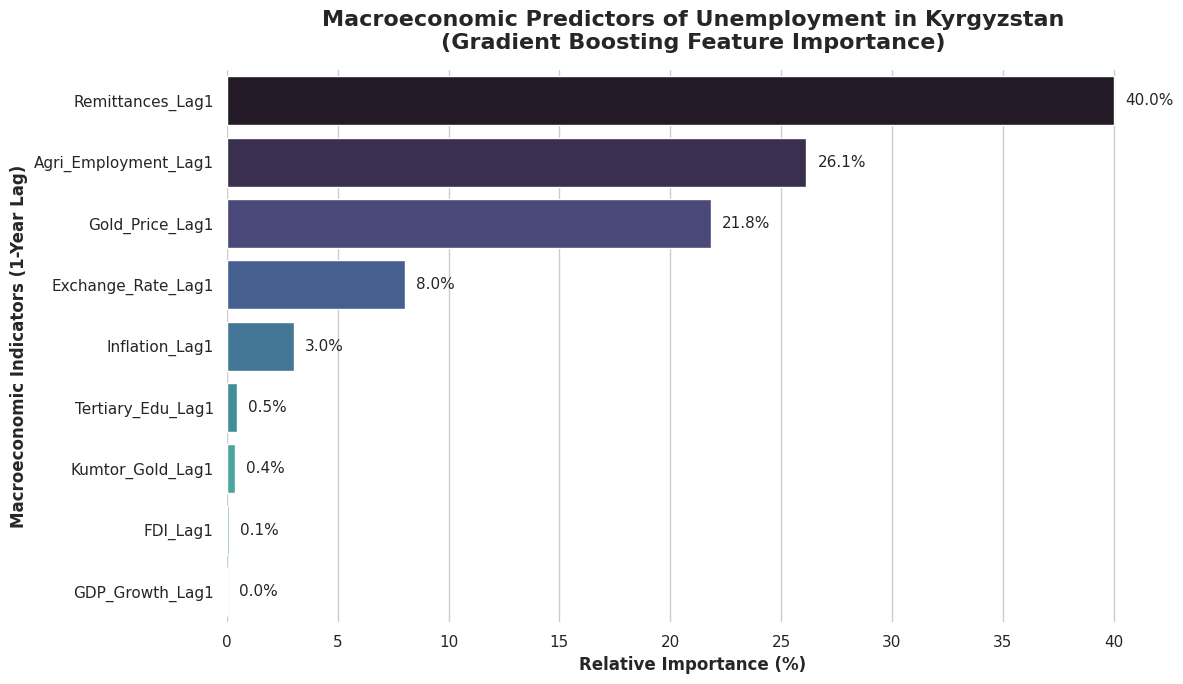

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Data Loading
df = pd.read_csv('/content/Finished_labor_data.csv')

# 2. Table Transposition (Years = rows)
df.set_index('Indicator Name', inplace=True)
df_ml = df.T
df_ml.index.name = 'Year'
df_ml = df_ml.reset_index()
df_ml['Year'] = df_ml['Year'].astype(int)

# 3. Column Renaming
col_mapping = {
    'Unemployment, total (% of total labor force) (national estimate)': 'Unemployment_Rate',
    'Exchange Rates, KGS per USD (annual mean) (NBKR)': 'Exchange_Rate',
    'Employment in agriculture (% of total employment) (modeled ILO estimate)': 'Agri_Employment',
    'Foreign direct investment, net inflows (% of GDP)': 'FDI',
    'Inflation, GDP deflator (annual % growth)': 'Inflation',
    'School enrollment, tertiary (% gross)': 'Tertiary_Edu',
    'Personal remittances, received (current US$) (millions)': 'Remittances',
    'GDP itself (annual % growth)': 'GDP_Growth',
    'Kumtor gold production (thousand of tonnes by year)': 'Kumtor_Gold',
    'Gold prices (US$)': 'Gold_Price'
}
df_ml = df_ml.rename(columns=col_mapping)

for col in df_ml.columns:
    if col != 'Year':
        df_ml[col] = pd.to_numeric(df_ml[col], errors='coerce')

# 4. Create Lags (Lag 1) for all 9 predictors
features = [
    'Exchange_Rate', 'Agri_Employment', 'FDI', 'Inflation',
    'Tertiary_Edu', 'Remittances', 'GDP_Growth', 'Kumtor_Gold', 'Gold_Price'
]

lag_features = []
for f in features:
    df_ml[f'{f}_Lag1'] = df_ml[f].shift(1)
    lag_features.append(f'{f}_Lag1')

df_ml = df_ml.dropna()

# 5. Define X and y
X = df_ml[lag_features]
y = df_ml['Unemployment_Rate']

# 6. Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# 7. Train Gradient Boosting
model_gb = GradientBoostingRegressor(n_estimators=100, random_state=42)
model_gb.fit(X_train, y_train)

# 8. Output Feature Importance
print("--- FEATURE IMPORTANCE (Gradient Boosting) ---")
importances_gb = pd.Series(model_gb.feature_importances_, index=lag_features).sort_values(ascending=False)

for feature, imp in importances_gb.items():
    print(f"{feature:25s}: {imp * 100:.1f}%")

# 9. Plot Feature Importance Graphically
# Set the visual style for a clean, professional look
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 7))

# Create a horizontal barplot using seaborn
# We multiply by 100 to show percentages
ax = sns.barplot(
    x=importances_gb.values * 100,
    y=importances_gb.index,
    palette="mako" # A professional blue-green color palette
)

# Add titles and labels tailored to your analysis
plt.title('Macroeconomic Predictors of Unemployment in Kyrgyzstan\n(Gradient Boosting Feature Importance)',
          fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Relative Importance (%)', fontsize=12, fontweight='bold')
plt.ylabel('Macroeconomic Indicators (1-Year Lag)', fontsize=12, fontweight='bold')

# Add the exact percentage text to the end of each bar for clarity
for p in ax.patches:
    width = p.get_width()
    # Add text slightly to the right of the bar
    plt.text(width + 0.5,
             p.get_y() + p.get_height() / 2,
             f'{width:.1f}%',
             ha='left',
             va='center',
             fontsize=11)

# Remove the top and right borders for a cleaner look
sns.despine(left=True, bottom=True)

# Adjust layout and display the plot
plt.tight_layout()
plt.show()

--- FEATURE IMPORTANCE (Random Forest) ---
Agri_Employment_Lag1     : 38.3%
Remittances_Lag1         : 22.1%
Gold_Price_Lag1          : 19.7%
Exchange_Rate_Lag1       : 8.7%
Kumtor_Gold_Lag1         : 3.8%
Tertiary_Edu_Lag1        : 3.0%
Inflation_Lag1           : 2.2%
GDP_Growth_Lag1          : 1.4%
FDI_Lag1                 : 0.8%


/tmp/ipykernel_8842/3431523574.py:74: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


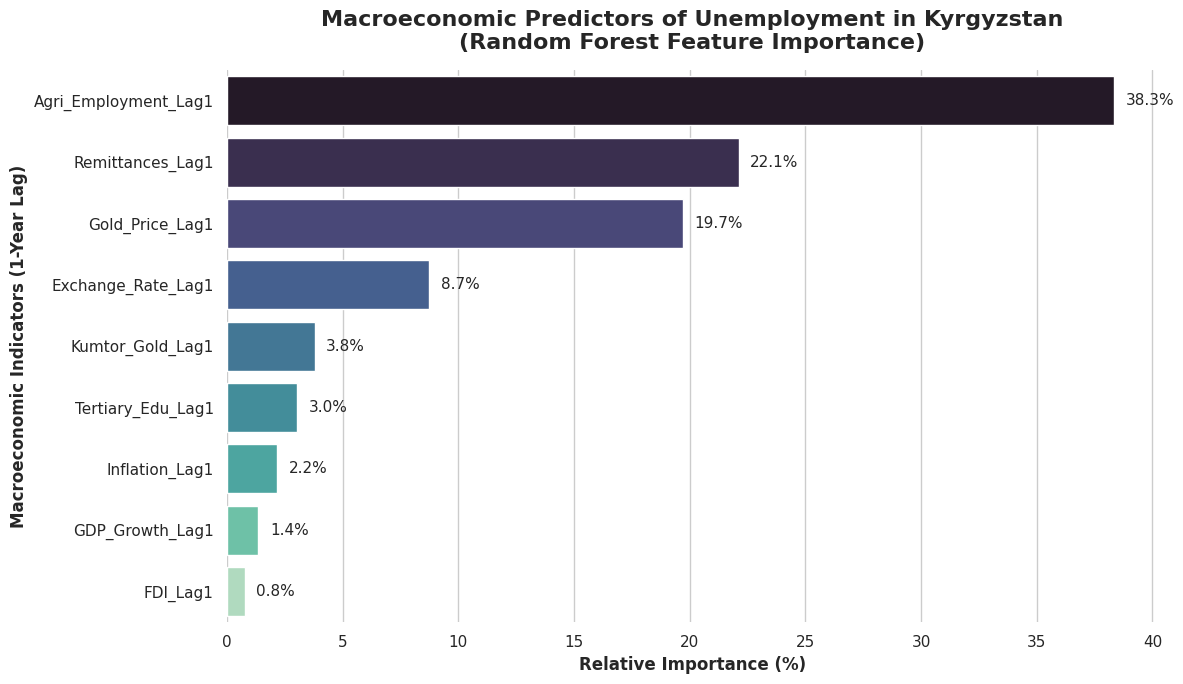

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Data Loading
df = pd.read_csv('/content/Finished_labor_data.csv')

# 2. Table Transposition (Years = rows)
df.set_index('Indicator Name', inplace=True)
df_ml = df.T
df_ml.index.name = 'Year'
df_ml = df_ml.reset_index()
df_ml['Year'] = df_ml['Year'].astype(int)

# 3. Column Renaming
col_mapping = {
    'Unemployment, total (% of total labor force) (national estimate)': 'Unemployment_Rate',
    'Exchange Rates, KGS per USD (annual mean) (NBKR)': 'Exchange_Rate',
    'Employment in agriculture (% of total employment) (modeled ILO estimate)': 'Agri_Employment',
    'Foreign direct investment, net inflows (% of GDP)': 'FDI',
    'Inflation, GDP deflator (annual % growth)': 'Inflation',
    'School enrollment, tertiary (% gross)': 'Tertiary_Edu',
    'Personal remittances, received (current US$) (millions)': 'Remittances',
    'GDP itself (annual % growth)': 'GDP_Growth',
    'Kumtor gold production (thousand of tonnes by year)': 'Kumtor_Gold',
    'Gold prices (US$)': 'Gold_Price'
}
df_ml = df_ml.rename(columns=col_mapping)

for col in df_ml.columns:
    if col != 'Year':
        df_ml[col] = pd.to_numeric(df_ml[col], errors='coerce')

# 4. Create Lags (Lag 1) for all 9 predictors
features = [
    'Exchange_Rate', 'Agri_Employment', 'FDI', 'Inflation',
    'Tertiary_Edu', 'Remittances', 'GDP_Growth', 'Kumtor_Gold', 'Gold_Price'
]

lag_features = []
for f in features:
    df_ml[f'{f}_Lag1'] = df_ml[f].shift(1)
    lag_features.append(f'{f}_Lag1')

df_ml = df_ml.dropna()

# 5. Define X and y
X = df_ml[lag_features]
y = df_ml['Unemployment_Rate']

# 6. Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# 7. Train Random Forest
model_rf = RandomForestRegressor(n_estimators=100, random_state=42)
model_rf.fit(X_train, y_train)

# 8. Output Feature Importance
print("--- FEATURE IMPORTANCE (Random Forest) ---")
importances_rf = pd.Series(model_rf.feature_importances_, index=lag_features).sort_values(ascending=False)

for feature, imp in importances_rf.items():
    print(f"{feature:25s}: {imp * 100:.1f}%")

# 9. Plot Feature Importance Graphically
# Set the visual style for a clean, professional look
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 7))

# Create a horizontal barplot using seaborn
# We multiply by 100 to show percentages
ax = sns.barplot(
    x=importances_rf.values * 100,
    y=importances_rf.index,
    palette="mako" # A professional blue-green color palette
)

# Add titles and labels tailored to your analysis
plt.title('Macroeconomic Predictors of Unemployment in Kyrgyzstan\n(Random Forest Feature Importance)',
          fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Relative Importance (%)', fontsize=12, fontweight='bold')
plt.ylabel('Macroeconomic Indicators (1-Year Lag)', fontsize=12, fontweight='bold')

# Add the exact percentage text to the end of each bar for clarity
for p in ax.patches:
    width = p.get_width()
    # Add text slightly to the right of the bar
    plt.text(width + 0.5,
             p.get_y() + p.get_height() / 2,
             f'{width:.1f}%',
             ha='left',
             va='center',
             fontsize=11)

# Remove the top and right borders for a cleaner look
sns.despine(left=True, bottom=True)

# Adjust layout and display the plot
plt.tight_layout()
plt.show()

--- FEATURE IMPORTANCE (XGBoost) ---
Agri_Employment_Lag1     : 88.6%
Exchange_Rate_Lag1       : 5.3%
Tertiary_Edu_Lag1        : 2.4%
Gold_Price_Lag1          : 1.9%
Inflation_Lag1           : 1.2%
FDI_Lag1                 : 0.5%
Kumtor_Gold_Lag1         : 0.0%
GDP_Growth_Lag1          : 0.0%
Remittances_Lag1         : 0.0%


/tmp/ipykernel_8842/3483623879.py:74: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


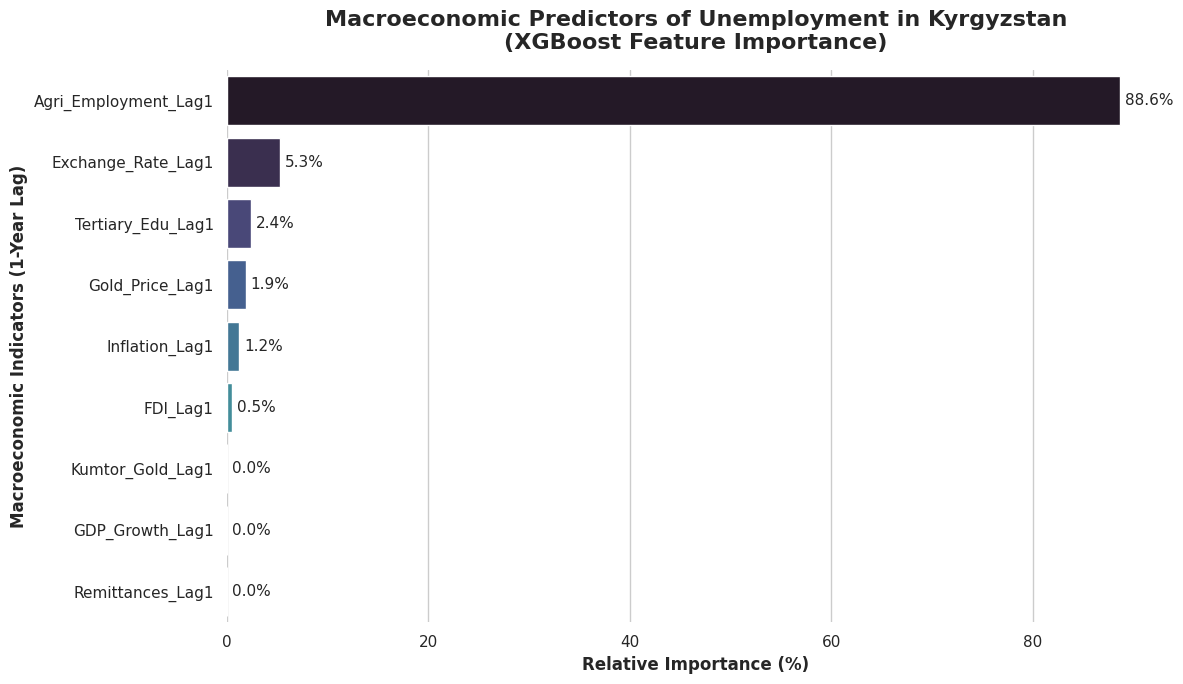

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Data Loading
df = pd.read_csv('/content/Finished_labor_data.csv')

# 2. Table Transposition (Years = rows)
df.set_index('Indicator Name', inplace=True)
df_ml = df.T
df_ml.index.name = 'Year'
df_ml = df_ml.reset_index()
df_ml['Year'] = df_ml['Year'].astype(int)

# 3. Column Renaming
col_mapping = {
    'Unemployment, total (% of total labor force) (national estimate)': 'Unemployment_Rate',
    'Exchange Rates, KGS per USD (annual mean) (NBKR)': 'Exchange_Rate',
    'Employment in agriculture (% of total employment) (modeled ILO estimate)': 'Agri_Employment',
    'Foreign direct investment, net inflows (% of GDP)': 'FDI',
    'Inflation, GDP deflator (annual % growth)': 'Inflation',
    'School enrollment, tertiary (% gross)': 'Tertiary_Edu',
    'Personal remittances, received (current US$) (millions)': 'Remittances',
    'GDP itself (annual % growth)': 'GDP_Growth',
    'Kumtor gold production (thousand of tonnes by year)': 'Kumtor_Gold',
    'Gold prices (US$)': 'Gold_Price'
}
df_ml = df_ml.rename(columns=col_mapping)

for col in df_ml.columns:
    if col != 'Year':
        df_ml[col] = pd.to_numeric(df_ml[col], errors='coerce')

# 4. Create Lags (Lag 1) for all 9 predictors
features = [
    'Exchange_Rate', 'Agri_Employment', 'FDI', 'Inflation',
    'Tertiary_Edu', 'Remittances', 'GDP_Growth', 'Kumtor_Gold', 'Gold_Price'
]

lag_features = []
for f in features:
    df_ml[f'{f}_Lag1'] = df_ml[f].shift(1)
    lag_features.append(f'{f}_Lag1')

df_ml = df_ml.dropna()

# 5. Define X and y
X = df_ml[lag_features]
y = df_ml['Unemployment_Rate']

# 6. Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# 7. Train XGBoost
# XGBoost is highly sensitive to parameters, these are standard starting points
model_xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
model_xgb.fit(X_train, y_train)

# 8. Output Feature Importance
print("--- FEATURE IMPORTANCE (XGBoost) ---")
importances_xgb = pd.Series(model_xgb.feature_importances_, index=lag_features).sort_values(ascending=False)

for feature, imp in importances_xgb.items():
    print(f"{feature:25s}: {imp * 100:.1f}%")

# 9. Plot Feature Importance Graphically
# Set the visual style for a clean, professional look
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 7))

# Create a horizontal barplot using seaborn
ax = sns.barplot(
    x=importances_xgb.values * 100,
    y=importances_xgb.index,
    palette="mako"
)

# Add titles and labels tailored to the final model
plt.title('Macroeconomic Predictors of Unemployment in Kyrgyzstan\n(XGBoost Feature Importance)',
          fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Relative Importance (%)', fontsize=12, fontweight='bold')
plt.ylabel('Macroeconomic Indicators (1-Year Lag)', fontsize=12, fontweight='bold')

# Add the exact percentage text to the end of each bar
for p in ax.patches:
    width = p.get_width()
    plt.text(width + 0.5,
             p.get_y() + p.get_height() / 2,
             f'{width:.1f}%',
             ha='left',
             va='center',
             fontsize=11)

# Remove the top and right borders
sns.despine(left=True, bottom=True)

# Adjust layout and display
plt.tight_layout()
plt.show()

#**Part 3: ARIMA-based features prediction**

---

In [ ]:
!pip install pmdarima #Installing ARIMA in Google Colab environment

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 11.7 MB/s eta 0:00:00


##**3.1 ADF Testing**

---



Cells below run the Augmented Dickey-Fuller (ADF) test to evaluate the stationarity of our key economic indicators.

ADF Test: A custom function iterates through our selected features, handles any missing values, and calculates the p-value. It outputs whether each time series is Stationary (p-value < 0.05) or Non-Stationary.

In [ ]:
import pandas as pd
import numpy as np
from statsmodels.tsa.stattools import adfuller
import warnings
warnings.filterwarnings("ignore") # Disabling unnecessary warnings

# 1. Loading and preparing data directly from CSV
print("⏳ Loading data and running the Dickey-Fuller test...\n")
df = pd.read_csv('/content/Finished_labor_data.csv')
df.set_index('Indicator Name', inplace=True)
df_ml = df.T.reset_index()
df_ml.rename(columns={'index': 'Year'}, inplace=True)

# 2. List of your source columns
features_to_check = [
    'Employment in agriculture (% of total employment) (modeled ILO estimate)',
    'Personal remittances, received (current US$) (millions)',
    'Gold prices (US$)',
    'Exchange Rates, KGS per USD (annual mean) (NBKR)',
    'Inflation, GDP deflator (annual % growth)'
]

# 3. Stationarity test function
def check_stationarity(series, col_name):
    # Convert to numbers and remove empty values (NaN)
    series_clean = pd.to_numeric(series, errors='coerce').dropna()

    # If there is too little data, the test will fail.
    if len(series_clean) < 10:
        return f"Показатель: {col_name[:50]}...\n⚠️ Недостаточно данных для теста\n"

    # Запускаем сам тест ADF
    result = adfuller(series_clean)
    p_value = result[1]

    # Forming a conclusion
    output = f"Indicator: {col_name[:50]}...\n"
    if p_value < 0.05:
        output += f" STATIONARY (p-value: {p_value:.4f})\n"
    else:
        output += f" NON-STATIONARY (p-value: {p_value:.4f})\n"
    return output + "-"*50

# 4. Launching a cycle for all indicators
for f in features_to_check:
    if f in df_ml.columns:
        print(check_stationarity(df_ml[f], f))
    else:
        print(f"❌ ERROR: Column '{f[:50]}...' not in file!\n" + "-"*50)

⏳ Loading data and running the Dickey-Fuller test...

Indicator: Employment in agriculture (% of total employment) ...
 STATIONARY (p-value: 0.0419)
--------------------------------------------------
Indicator: Personal remittances, received (current US$) (mill...
 NON-STATIONARY (p-value: 0.4566)
--------------------------------------------------
Indicator: Gold prices (US$)...
 NON-STATIONARY (p-value: 0.2360)
--------------------------------------------------
Indicator: Exchange Rates, KGS per USD (annual mean) (NBKR)...
 NON-STATIONARY (p-value: 0.9113)
--------------------------------------------------
Indicator: Inflation, GDP deflator (annual % growth)...
 NON-STATIONARY (p-value: 0.5285)
--------------------------------------------------


In [ ]:
import pandas as pd
import numpy as np
from statsmodels.tsa.stattools import adfuller
import warnings
warnings.filterwarnings("ignore")

# 1. Loading and preparing data
print("⏳ Loading the data and running the Dickey-Fuller test for FIRST DIFFERENCES (d=1)...\n")
df = pd.read_csv('/content/Finished_labor_data.csv')
df.set_index('Indicator Name', inplace=True)
df_ml = df.T.reset_index()
df_ml.rename(columns={'index': 'Year'}, inplace=True)

# 2. List of source columns
features_to_check = [
    'Personal remittances, received (current US$) (millions)',
    'Gold prices (US$)',
    'Exchange Rates, KGS per USD (annual mean) (NBKR)',
    'Inflation, GDP deflator (annual % growth)'
]

# 3. Stationarity check function
def check_stationarity_diff(series, col_name):
    series_numeric = pd.to_numeric(series, errors='coerce')

    # Take the FIRST DIFFERENCE and immediately delete the first empty row (NaN)
    series_diff = series_numeric.diff(1).dropna()

    if len(series_diff) < 10:
        return f"Indicator: {col_name[:50]}...\n⚠️ Not enough data\n"

    result = adfuller(series_diff)
    p_value = result[1]

    output = f"Indicator: {col_name[:50]}... (1st Diff)\n"
    if p_value < 0.05:
        output += f" STATIONARY (p-value: {p_value:.4f})\n"
    else:
        output += f" NON-STATIONARY (p-value: {p_value:.4f})\n"
    return output + "-"*50

for f in features_to_check:
    if f in df_ml.columns:
        print(check_stationarity_diff(df_ml[f], f))
    else:
        print(f"❌ ERROR: Column '{f[:50]}...' not in file!\n" + "-"*50)

⏳ Loading the data and running the Dickey-Fuller test for FIRST DIFFERENCES (d=1)...

Indicator: Personal remittances, received (current US$) (mill... (1st Diff)
 STATIONARY (p-value: 0.0001)
--------------------------------------------------
Indicator: Gold prices (US$)... (1st Diff)
 NON-STATIONARY (p-value: 0.2742)
--------------------------------------------------
Indicator: Exchange Rates, KGS per USD (annual mean) (NBKR)... (1st Diff)
 NON-STATIONARY (p-value: 0.7122)
--------------------------------------------------
Indicator: Inflation, GDP deflator (annual % growth)... (1st Diff)
 NON-STATIONARY (p-value: 0.5416)
--------------------------------------------------


In [ ]:
import pandas as pd
import numpy as np
from statsmodels.tsa.stattools import adfuller
import warnings
warnings.filterwarnings("ignore")

# 1.
print("⏳ Loading the data and running the Dickey-Fuller test for SECOND DIFFERENCES (d=2)...\n")
df = pd.read_csv('/content/Finished_labor_data.csv')
df.set_index('Indicator Name', inplace=True)
df_ml = df.T.reset_index()
df_ml.rename(columns={'index': 'Year'}, inplace=True)

# 2.
features_to_check = [
    'Gold prices (US$)',
    'Exchange Rates, KGS per USD (annual mean) (NBKR)',
    'Inflation, GDP deflator (annual % growth)'
]

# 3.
def check_stationarity_diff(series, col_name):
    series_numeric = pd.to_numeric(series, errors='coerce')

    # 2nd diff
    series_diff = series_numeric.diff(1).diff(1).dropna()

    if len(series_diff) < 10:
        return f"Indicator: {col_name[:50]}...\n⚠️ Not enough data\n"

    result = adfuller(series_diff)
    p_value = result[1]

    output = f"Indicator: {col_name[:50]}... (2nd diff)\n"
    if p_value < 0.05:
        output += f" STATIONARY (p-value: {p_value:.4f})\n"
    else:
        output += f" NON-STATIONARY (p-value: {p_value:.4f})\n"
    return output + "-"*50

# 4.
for f in features_to_check:
    if f in df_ml.columns:
        print(check_stationarity_diff(df_ml[f], f))
    else:
        print(f"❌ ERROR: Column '{f[:50]}...' not in file!\n" + "-"*50)

⏳ Loading the data and running the Dickey-Fuller test for SECOND DIFFERENCES (d=2)...

Indicator: Gold prices (US$)... (2nd diff)
 NON-STATIONARY (p-value: 0.5917)
--------------------------------------------------
Indicator: Exchange Rates, KGS per USD (annual mean) (NBKR)... (2nd diff)
 STATIONARY (p-value: 0.0000)
--------------------------------------------------
Indicator: Inflation, GDP deflator (annual % growth)... (2nd diff)
 STATIONARY (p-value: 0.0000)
--------------------------------------------------


##**3.2 Time Series Features Forecasting with Auto-ARIMA**

---

The following cells execute predictive modeling for our key indicators (based on Feature Importance test): Exchange Rates, Employment in Agriculture, Inflation, Personal Remittances, and Gold Prices. To ensure the most accurate predictions, we use the pmdarima library to automatically identify the best-fitting model for each unique variable.

The standard workflow across these cells includes:

Target Extraction: Isolating the specific indicator from our dataset and formatting the years into a standard time series index.

Parameter Optimization: Running auto_arima to automatically discover the optimal ARIMA parameters (p, d, q). The differencing parameter (d) is adjusted for each indicator based on the results of our earlier Dickey-Fuller stationarity tests.

Future Projection: Generating a 6-year future forecast, complete with calculated upper and lower 95% confidence bounds.

Visualization: Plotting the historical data alongside the predicted future trajectory and shaded confidence intervals for clear visual analysis.

--- Starting forecast for: Gold prices (US$) ---
Searching for optimal ARIMA parameters...
Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=298.004, Time=0.14 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=296.997, Time=0.26 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=295.431, Time=0.20 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=301.243, Time=0.06 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=297.426, Time=1.49 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=297.418, Time=0.26 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=1.26 sec
 ARIMA(0,1,1)(0,0,0)[0]             : AIC=296.600, Time=0.09 sec

Best model:  ARIMA(0,1,1)(0,0,0)[0] intercept
Total fit time: 3.815 seconds

--- Best Model ---
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   24
Model:               SARIMAX(0, 1, 1)   Log Likelihood                -144.716
Date:           

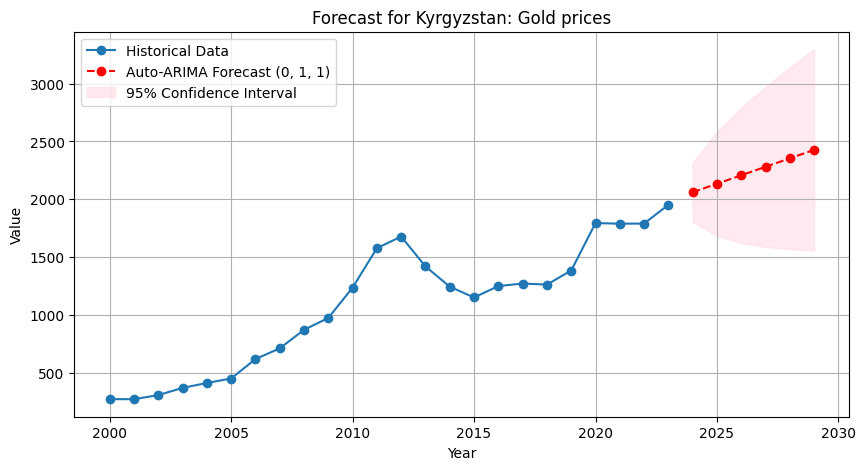

In [ ]:
# Gold prices AUTO-ARIMA
import pandas as pd
import matplotlib.pyplot as plt
import pmdarima as pm

INDICATOR_NAME = 'Gold prices'
FORECAST_STEPS = 6

# 1. Load dataset
df = pd.read_csv('Finished_labor_data.csv')

# 2. Dynamic search for the required row
target_row = df[df['Indicator Name'].str.contains(INDICATOR_NAME, case=False, na=False)].iloc[0]
full_name = target_row['Indicator Name']

print(f"--- Starting forecast for: {full_name} ---")

# 3. Format data for time series
years = target_row.index[1:]
values = pd.to_numeric(target_row.values[1:])

ts_df = pd.DataFrame({
    'Year': pd.to_datetime(years, format='%Y'),
    'Target_Value': values
})
ts_df.set_index('Year', inplace=True)

# 4. Find optimal ARIMA parameters
print("Searching for optimal ARIMA parameters...")
auto_model = pm.auto_arima(
    ts_df['Target_Value'],
    start_p=0, max_p=3,
    start_q=0, max_q=3,
    d=None,
    seasonal=False,
    trace=True,
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True
)

print("\n--- Best Model ---")
print(auto_model.summary())

# 5. Create future forecast
future_forecast, confidence_intervals = auto_model.predict(n_periods=FORECAST_STEPS, return_conf_int=True)

last_year = ts_df.index[-1].year
future_years = [last_year + i for i in range(1, FORECAST_STEPS + 1)]

forecast_df = pd.DataFrame({
    'Year': future_years,
    'Forecasted_Value': future_forecast.values,
    'Lower_Bound_95%': confidence_intervals[:, 0],
    'Upper_Bound_95%': confidence_intervals[:, 1]
})

print(f"\n--- Forecast for the next {FORECAST_STEPS} years ---")
print(forecast_df.to_string(index=False))

# 6. Visualization
plt.figure(figsize=(10, 5))
plt.plot(ts_df.index.year, ts_df['Target_Value'], label='Historical Data', marker='o')
plt.plot(future_years, future_forecast, color='red', label=f'Auto-ARIMA Forecast {auto_model.order}', linestyle='--', marker='o')
plt.fill_between(future_years, confidence_intervals[:, 0], confidence_intervals[:, 1], color='pink', alpha=0.3, label='95% Confidence Interval')

plt.title(f'Forecast for Kyrgyzstan: {INDICATOR_NAME}')
plt.xlabel('Year')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()

--- Starting forecast for: Personal remittances, received (current US$) (millions) ---
Searching for optimal ARIMA parameters...
Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=324.977, Time=0.02 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=326.976, Time=0.30 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=326.963, Time=1.03 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=327.694, Time=0.03 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=328.075, Time=2.11 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0] intercept
Total fit time: 3.502 seconds

--- Best Model ---
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   24
Model:               SARIMAX(0, 1, 0)   Log Likelihood                -160.489
Date:                Tue, 21 Apr 2026   AIC                            324.977
Time:                        20:51:47   BIC                            327.248
Sample:    

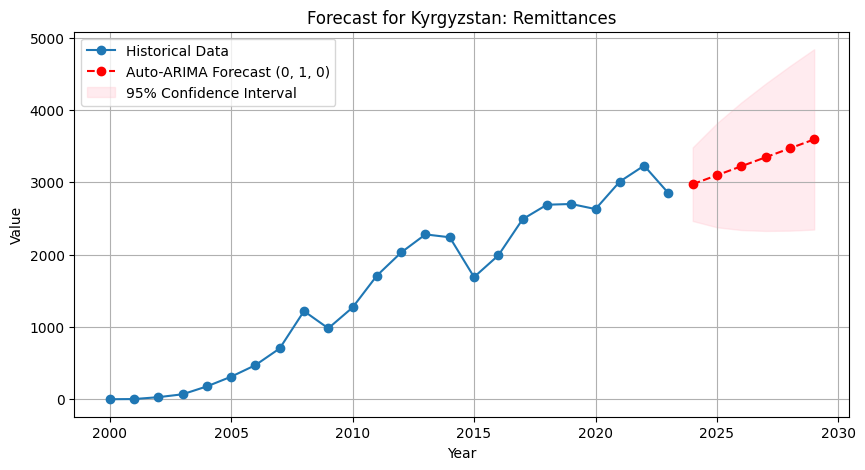

In [ ]:
# Personal remittances AUTO-ARIMA
import pandas as pd
import matplotlib.pyplot as plt
import pmdarima as pm

INDICATOR_NAME = 'Remittances'
FORECAST_STEPS = 6

# 1. Load dataset
df = pd.read_csv('Finished_labor_data.csv')

# 2. Dynamic search for the required row
target_row = df[df['Indicator Name'].str.contains(INDICATOR_NAME, case=False, na=False)].iloc[0]
full_name = target_row['Indicator Name']

print(f"--- Starting forecast for: {full_name} ---")

# 3. Format data for time series
years = target_row.index[1:]
values = pd.to_numeric(target_row.values[1:])

ts_df = pd.DataFrame({
    'Year': pd.to_datetime(years, format='%Y'),
    'Target_Value': values
})
ts_df.set_index('Year', inplace=True)

# 4. Find optimal ARIMA parameters
print("Searching for optimal ARIMA parameters...")
auto_model = pm.auto_arima(
    ts_df['Target_Value'],
    start_p=0, max_p=5,
    start_q=0, max_q=5,
    d=1,
    seasonal=False,
    trace=True,
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True
)

print("\n--- Best Model ---")
print(auto_model.summary())

# 5. Create future forecast
future_forecast, confidence_intervals = auto_model.predict(n_periods=FORECAST_STEPS, return_conf_int=True)

last_year = ts_df.index[-1].year
future_years = [last_year + i for i in range(1, FORECAST_STEPS + 1)]

forecast_df = pd.DataFrame({
    'Year': future_years,
    'Forecasted_Value': future_forecast.values,
    'Lower_Bound_95%': confidence_intervals[:, 0],
    'Upper_Bound_95%': confidence_intervals[:, 1]
})

print(f"\n--- Forecast for the next {FORECAST_STEPS} years ---")
print(forecast_df.to_string(index=False))

# 6. Visualization
plt.figure(figsize=(10, 5))
plt.plot(ts_df.index.year, ts_df['Target_Value'], label='Historical Data', marker='o')
plt.plot(future_years, future_forecast, color='red', label=f'Auto-ARIMA Forecast {auto_model.order}', linestyle='--', marker='o')
plt.fill_between(future_years, confidence_intervals[:, 0], confidence_intervals[:, 1], color='pink', alpha=0.3, label='95% Confidence Interval')

plt.title(f'Forecast for Kyrgyzstan: {INDICATOR_NAME}')
plt.xlabel('Year')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()

--- Starting forecast for: Inflation, GDP deflator (annual % growth) ---
Searching for optimal ARIMA parameters...
Performing stepwise search to minimize aic
 ARIMA(0,2,0)(0,0,0)[0] intercept   : AIC=175.167, Time=0.05 sec
 ARIMA(1,2,0)(0,0,0)[0] intercept   : AIC=172.855, Time=0.21 sec
 ARIMA(0,2,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.88 sec
 ARIMA(0,2,0)(0,0,0)[0]             : AIC=173.297, Time=0.04 sec
 ARIMA(2,2,0)(0,0,0)[0] intercept   : AIC=163.073, Time=0.16 sec
 ARIMA(3,2,0)(0,0,0)[0] intercept   : AIC=164.439, Time=0.24 sec
 ARIMA(2,2,1)(0,0,0)[0] intercept   : AIC=163.828, Time=0.18 sec
 ARIMA(1,2,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.31 sec
 ARIMA(3,2,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.79 sec
 ARIMA(2,2,0)(0,0,0)[0]             : AIC=161.884, Time=0.26 sec
 ARIMA(1,2,0)(0,0,0)[0]             : AIC=171.087, Time=0.04 sec
 ARIMA(3,2,0)(0,0,0)[0]             : AIC=163.375, Time=0.08 sec
 ARIMA(2,2,1)(0,0,0)[0]             : AIC=162.944, Time=0.41 sec
 ARIMA(1,

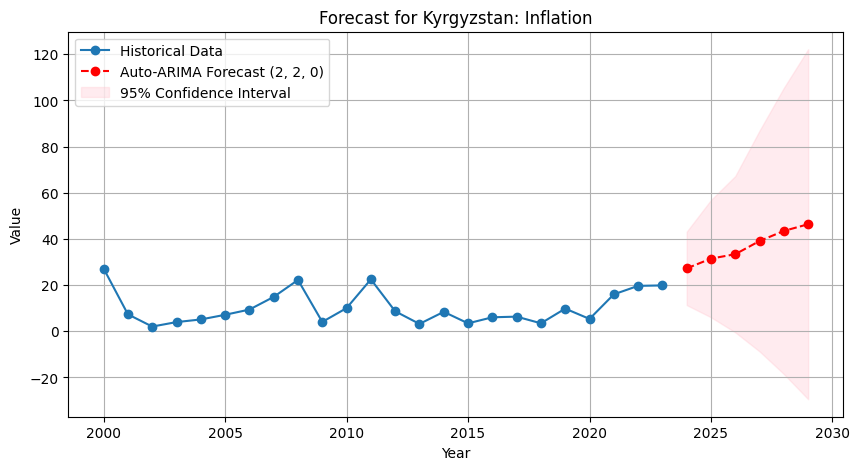

In [ ]:
# INFLATION AUTO-ARIMA
import pandas as pd
import matplotlib.pyplot as plt
import pmdarima as pm

INDICATOR_NAME = 'Inflation'
FORECAST_STEPS = 6

# 1. Load dataset
df = pd.read_csv('Finished_labor_data.csv')

# 2. Dynamic search for the required row
target_row = df[df['Indicator Name'].str.contains(INDICATOR_NAME, case=False, na=False)].iloc[0]
full_name = target_row['Indicator Name']

print(f"--- Starting forecast for: {full_name} ---")

# 3. Format data for time series
years = target_row.index[1:]
values = pd.to_numeric(target_row.values[1:])

ts_df = pd.DataFrame({
    'Year': pd.to_datetime(years, format='%Y'),
    'Target_Value': values
})
ts_df.set_index('Year', inplace=True)

# 4. Find optimal ARIMA parameters
print("Searching for optimal ARIMA parameters...")
auto_model = pm.auto_arima(
    ts_df['Target_Value'],
    start_p=0, max_p=5,
    start_q=0, max_q=5,
    d=2,
    seasonal=False,
    trace=True,
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True
)

print("\n--- Best Model ---")
print(auto_model.summary())

# 5. Create future forecast
future_forecast, confidence_intervals = auto_model.predict(n_periods=FORECAST_STEPS, return_conf_int=True)

last_year = ts_df.index[-1].year
future_years = [last_year + i for i in range(1, FORECAST_STEPS + 1)]

forecast_df = pd.DataFrame({
    'Year': future_years,
    'Forecasted_Value': future_forecast.values,
    'Lower_Bound_95%': confidence_intervals[:, 0],
    'Upper_Bound_95%': confidence_intervals[:, 1]
})

print(f"\n--- Forecast for the next {FORECAST_STEPS} years ---")
print(forecast_df.to_string(index=False))

# 6. Visualization
plt.figure(figsize=(10, 5))
plt.plot(ts_df.index.year, ts_df['Target_Value'], label='Historical Data', marker='o')
plt.plot(future_years, future_forecast, color='red', label=f'Auto-ARIMA Forecast {auto_model.order}', linestyle='--', marker='o')
plt.fill_between(future_years, confidence_intervals[:, 0], confidence_intervals[:, 1], color='pink', alpha=0.3, label='95% Confidence Interval')

plt.title(f'Forecast for Kyrgyzstan: {INDICATOR_NAME}')
plt.xlabel('Year')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()

--- Starting forecast for: Employment in agriculture (% of total employment) (modeled ILO estimate) ---
Searching for optimal ARIMA parameters...
Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=240.850, Time=0.14 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.09 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=inf, Time=0.75 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=107.612, Time=1.78 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=106.355, Time=2.38 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=inf, Time=0.29 sec
 ARIMA(3,0,1)(0,0,0)[0]             : AIC=inf, Time=0.37 sec
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=108.006, Time=0.19 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=107.027, Time=0.12 sec
 ARIMA(3,0,0)(0,0,0)[0]             : AIC=inf, Time=0.06 sec
 ARIMA(3,0,2)(0,0,0)[0]             : AIC=inf, Time=0.20 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : AIC=105.323, Time=0.15 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=107.262, Time

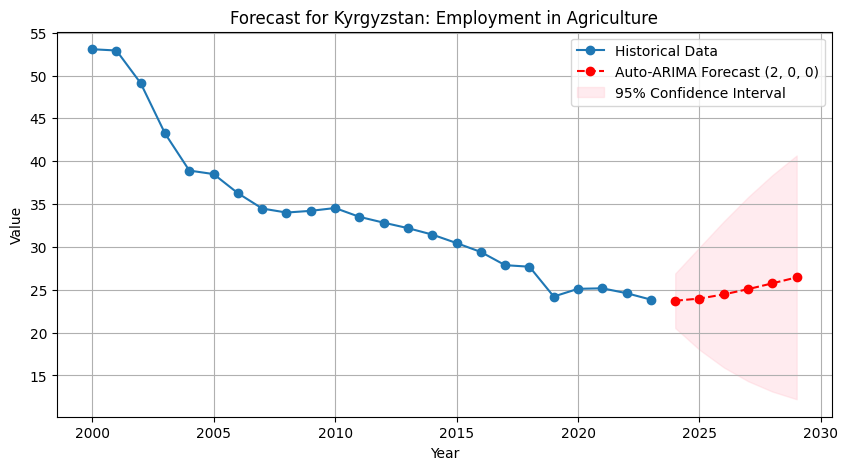

In [ ]:
# EMPLOYMENT IN AGRICULTURE AUTO-ARIMA
import pandas as pd
import matplotlib.pyplot as plt
import pmdarima as pm

INDICATOR_NAME = 'Agriculture'
FORECAST_STEPS = 6

# 1. Load dataset
df = pd.read_csv('Finished_labor_data.csv')

# 2. Dynamic search for the required indicator
target_row = df[df['Indicator Name'].str.contains(INDICATOR_NAME, case=False, na=False)].iloc[0]
full_name = target_row['Indicator Name'] # Save the full official name for the plot

print(f"--- Starting forecast for: {full_name} ---")

# 3. Format data for time series
years = target_row.index[1:]
values = pd.to_numeric(target_row.values[1:])

# Use a universal name 'Target_Value'
ts_df = pd.DataFrame({
    'Year': pd.to_datetime(years, format='%Y'),
    'Target_Value': values
})
ts_df.set_index('Year', inplace=True)

# 4. Find optimal ARIMA parameters
print("Searching for optimal ARIMA parameters...")
auto_model = pm.auto_arima(
    ts_df['Target_Value'],
    start_p=0, max_p=3,
    start_q=0, max_q=3,
    d=0,
    seasonal=False,
    trace=True,
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True
)

print("\n--- Best Model ---")
print(auto_model.summary())

# 5. Create future forecast
future_forecast, confidence_intervals = auto_model.predict(n_periods=FORECAST_STEPS, return_conf_int=True)

last_year = ts_df.index[-1].year
future_years = [last_year + i for i in range(1, FORECAST_STEPS + 1)]

# Universal results table
forecast_df = pd.DataFrame({
    'Year': future_years,
    'Forecasted_Value': future_forecast.values,
    'Lower_Bound_95%': confidence_intervals[:, 0],
    'Upper_Bound_95%': confidence_intervals[:, 1]
})

print(f"\n--- Forecast for the next {FORECAST_STEPS} years ---")
print(forecast_df.to_string(index=False))

# 6. Visualization (titles are generated automatically)
plt.figure(figsize=(10, 5))
plt.plot(ts_df.index.year, ts_df['Target_Value'], label='Historical Data', marker='o')
plt.plot(future_years, future_forecast, color='red', label=f'Auto-ARIMA Forecast {auto_model.order}', linestyle='--', marker='o')

plt.fill_between(future_years, confidence_intervals[:, 0], confidence_intervals[:, 1], color='pink', alpha=0.3, label='95% Confidence Interval')

plt.title('Forecast for Kyrgyzstan: Employment in Agriculture')
plt.xlabel('Year')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()

--- Starting forecast for: Exchange Rates, KGS per USD (annual mean) (NBKR) ---
Searching for optimal ARIMA parameters...
Performing stepwise search to minimize aic
 ARIMA(0,2,0)(0,0,0)[0] intercept   : AIC=126.102, Time=0.02 sec
 ARIMA(1,2,0)(0,0,0)[0] intercept   : AIC=128.077, Time=0.05 sec
 ARIMA(0,2,1)(0,0,0)[0] intercept   : AIC=inf, Time=1.09 sec
 ARIMA(0,2,0)(0,0,0)[0]             : AIC=124.129, Time=0.02 sec
 ARIMA(1,2,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.49 sec

Best model:  ARIMA(0,2,0)(0,0,0)[0]          
Total fit time: 1.669 seconds

--- Best Model ---
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   24
Model:               SARIMAX(0, 2, 0)   Log Likelihood                 -61.065
Date:                Wed, 29 Apr 2026   AIC                            124.129
Time:                        15:15:36   BIC                            125.220
Sample:                   

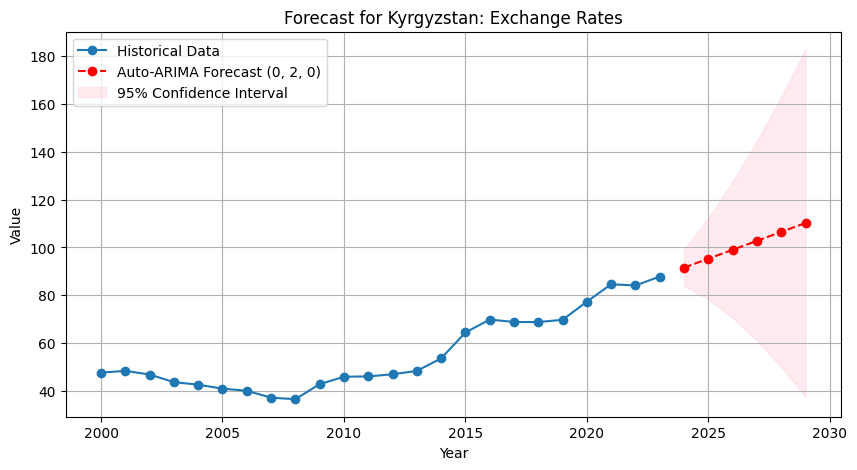

In [ ]:
# EXCHANGE RATE AUTO-ARIMA
import pandas as pd
import matplotlib.pyplot as plt
import pmdarima as pm

INDICATOR_NAME = 'Exchange'
FORECAST_STEPS = 6

# 1. Load dataset
df = pd.read_csv('Finished_labor_data.csv')

# 2. Dynamic search for the required indicator
target_row = df[df['Indicator Name'].str.contains(INDICATOR_NAME, case=False, na=False)].iloc[0]
full_name = target_row['Indicator Name']

print(f"--- Starting forecast for: {full_name} ---")

# 3. Format data for time series
years = target_row.index[1:]
values = pd.to_numeric(target_row.values[1:])

# Use a universal name 'Target_Value'
ts_df = pd.DataFrame({
    'Year': pd.to_datetime(years, format='%Y'),
    'Target_Value': values
})
ts_df.set_index('Year', inplace=True)

# 4. Find optimal ARIMA parameters
print("Searching for optimal ARIMA parameters...")
auto_model = pm.auto_arima(
    ts_df['Target_Value'],
    start_p=0, max_p=3,
    start_q=0, max_q=3,
    d=2, #Based on ADF testing
    seasonal=False,
    trace=True,
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True
)

print("\n--- Best Model ---")
print(auto_model.summary())

# 5. Create future forecast
future_forecast, confidence_intervals = auto_model.predict(n_periods=FORECAST_STEPS, return_conf_int=True)

last_year = ts_df.index[-1].year
future_years = [last_year + i for i in range(1, FORECAST_STEPS + 1)]

# Universal results table
forecast_df = pd.DataFrame({
    'Year': future_years,
    'Forecasted_Value': future_forecast.values,
    'Lower_Bound_95%': confidence_intervals[:, 0],
    'Upper_Bound_95%': confidence_intervals[:, 1]
})

print(f"\n--- Forecast for the next {FORECAST_STEPS} years ---")
print(forecast_df.to_string(index=False))

# 6. Visualization (titles are generated automatically)
plt.figure(figsize=(10, 5))
plt.plot(ts_df.index.year, ts_df['Target_Value'], label='Historical Data', marker='o')
plt.plot(future_years, future_forecast, color='red', label=f'Auto-ARIMA Forecast {auto_model.order}', linestyle='--', marker='o')

plt.fill_between(future_years, confidence_intervals[:, 0], confidence_intervals[:, 1], color='pink', alpha=0.3, label='95% Confidence Interval')

plt.title(f'Forecast for Kyrgyzstan: Exchange Rates')
plt.xlabel('Year')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()

#**Part 4: Machine Learning**

---
some text


##4.1 ML Models testing

---

To ensure the robustness of our machine learning models on time-series data, we use Forward Chaining (Rolling Forecast). Unlike standard cross-validation, this method respects the temporal order of data by training on a growing historical window and testing on the immediate following year.

We evaluate the following models using MAE (Mean Absolute Error), RMSE (Root Mean Squared Error), and R² (Coefficient of Determination):

Linear Regression: Baseline statistical model.  
SVR (Support Vector Regressor): Effective for non-linear relationships in smaller datasets.  
Random Forest: Ensemble method using bagging.  
Gradient Boosting: Sequential ensemble method.  
XGBoost: Optimized gradient boosting.

In [ ]:
#Linear Regression
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Loading and Preparation
df = pd.read_csv('/content/Finished_labor_data.csv')
df.set_index('Indicator Name', inplace=True)
df_ml = df.T.reset_index()
df_ml.rename(columns={'index': 'Year'}, inplace=True)
df_ml['Year'] = df_ml['Year'].astype(int)

# 2. Select TOP-5 features
col_mapping = {
    'Unemployment, total (% of total labor force) (national estimate)': 'Unemployment_Rate',
    'Employment in agriculture (% of total employment) (modeled ILO estimate)': 'Agri_Employment',
    'Personal remittances, received (current US$) (millions)': 'Remittances',
    'Gold prices (US$)': 'Gold_Price',
    'Exchange Rates, KGS per USD (annual mean) (NBKR)': 'Exchange_Rate',
    'Inflation, GDP deflator (annual % growth)': 'Inflation'
}
df_ml = df_ml.rename(columns=col_mapping)

# Convert columns to numeric format
features_to_convert = ['Unemployment_Rate', 'Agri_Employment',
                       'Remittances', 'Gold_Price', 'Exchange_Rate', 'Inflation']
for col in features_to_convert:
    if col in df_ml.columns:
        df_ml[col] = pd.to_numeric(df_ml[col], errors='coerce')

# Adjust historical outliers (Interpolation of 2010 political crisis and 2020 COVID)
df_ml.loc[df_ml['Year'] == 2020, 'Unemployment_Rate'] = 5.30
df_ml.loc[df_ml['Year'] == 2010, 'Unemployment_Rate'] = 7.94

# 3. Automatic Lag creation (shift by 1 year) for all TOP-5 factors
features = ['Agri_Employment',
            'Remittances', 'Gold_Price', 'Exchange_Rate', 'Inflation']
lag_features = []

for f in features:
    df_ml[f'{f}_Lag1'] = df_ml[f].shift(1)
    lag_features.append(f'{f}_Lag1')

# Remove empty rows resulting from the shift
df_ml = df_ml.dropna(subset=['Unemployment_Rate'] + lag_features).reset_index(drop=True)

X = df_ml[lag_features]
y = df_ml['Unemployment_Rate']
years = df_ml['Year']

# ==========================================
# 4. FORWARD CHAINING (Linear Regression)
# ==========================================
# Initialize classical linear model
model = LinearRegression()

actuals = []
predictions = []
test_years = []

min_train_size = 7

print("--- FORECAST EVOLUTION (LINEAR REGRESSION FORWARD CHAINING) ---")
for i in range(min_train_size, len(X)):
    X_train = X.iloc[:i]
    y_train = y.iloc[:i]
    X_test = X.iloc[i:i+1]
    y_test = y.iloc[i:i+1]
    current_year = years.iloc[i]

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)[0]

    actuals.append(y_test.values[0])
    predictions.append(y_pred)
    test_years.append(current_year)

    # Calculate cumulative R2
    if len(actuals) > 1:
        current_r2 = r2_score(actuals, predictions)
        r2_str = f"{current_r2:7.4f}"
    else:
        r2_str = "    N/A (insufficient data)"

    print(f"Year: {current_year} | Trained on years: 2001-{years.iloc[i-1]} | Actual: {y_test.values[0]:.2f} -> Predicted: {y_pred:.2f} | Cumul. R²: {r2_str}")

# 5. Final absolute metrics
mae = mean_absolute_error(actuals, predictions)
mse = mean_squared_error(actuals, predictions)
rmse = np.sqrt(mse)
r2_final = r2_score(actuals, predictions)

print("\n--- FINAL RESULT LINEAR REGRESSION (Period 2011-2023) ---")
print(f"Final MAE:  {mae:.4f}")
print(f"Final MSE:  {mse:.4f}")
print(f"Final RMSE: {rmse:.4f}")
print(f"Final R²:   {r2_final:.4f}")

--- FORECAST EVOLUTION (LINEAR REGRESSION FORWARD CHAINING) ---
Year: 2008 | Trained on years: 2001-2007 | Actual: 8.22 -> Predicted: 8.07 | Cumul. R²:     N/A (insufficient data)
Year: 2009 | Trained on years: 2001-2008 | Actual: 8.41 -> Predicted: 12.68 | Cumul. R²: -1011.3752
Year: 2010 | Trained on years: 2001-2009 | Actual: 7.94 -> Predicted: 10.62 | Cumul. R²: -226.8303
Year: 2011 | Trained on years: 2001-2010 | Actual: 7.46 -> Predicted: 6.69 | Cumul. R²: -49.9511
Year: 2012 | Trained on years: 2001-2011 | Actual: 5.91 -> Predicted: 6.24 | Cumul. R²: -5.4925
Year: 2013 | Trained on years: 2001-2012 | Actual: 5.53 -> Predicted: 8.84 | Cumul. R²: -3.9075
Year: 2014 | Trained on years: 2001-2013 | Actual: 5.05 -> Predicted: 5.46 | Cumul. R²: -2.1884
Year: 2015 | Trained on years: 2001-2014 | Actual: 4.20 -> Predicted: 0.53 | Cumul. R²: -1.7849
Year: 2016 | Trained on years: 2001-2015 | Actual: 4.01 -> Predicted: 0.55 | Cumul. R²: -1.5969
Year: 2017 | Trained on years: 2001-2016 | A

In [ ]:
# SVR (Support Vector Regressor)
import pandas as pd
import numpy as np
from sklearn.svm import SVR # Import SVR
from sklearn.preprocessing import StandardScaler # Scaler for SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Loading and Preparation
df = pd.read_csv('/content/Finished_labor_data.csv')
df.set_index('Indicator Name', inplace=True)
df_ml = df.T.reset_index()
df_ml.rename(columns={'index': 'Year'}, inplace=True)
df_ml['Year'] = df_ml['Year'].astype(int)

# 2. Keep TOP-5 features
col_mapping = {
    'Unemployment, total (% of total labor force) (national estimate)': 'Unemployment_Rate',
    'Employment in agriculture (% of total employment) (modeled ILO estimate)': 'Agri_Employment',
    'Personal remittances, received (current US$) (millions)': 'Remittances',
    'Gold prices (US$)': 'Gold_Price',
    'Exchange Rates, KGS per USD (annual mean) (NBKR)': 'Exchange_Rate',
    'Inflation, GDP deflator (annual % growth)': 'Inflation'
}
df_ml = df_ml.rename(columns=col_mapping)

# Convert columns to numeric format
features_to_convert = ['Unemployment_Rate', 'Agri_Employment',
                       'Remittances', 'Gold_Price', 'Exchange_Rate', 'Inflation']
for col in features_to_convert:
    if col in df_ml.columns:
        df_ml[col] = pd.to_numeric(df_ml[col], errors='coerce')

# Adjust historical outliers (Interpolation of 2010 political crisis and 2020 COVID)
df_ml.loc[df_ml['Year'] == 2020, 'Unemployment_Rate'] = 5.30
df_ml.loc[df_ml['Year'] == 2010, 'Unemployment_Rate'] = 7.94

# 3. Automatic Lag creation (shift by 1 year) for all TOP-5 factors
features = ['Agri_Employment',
            'Remittances', 'Gold_Price', 'Exchange_Rate', 'Inflation']
lag_features = []

for f in features:
    df_ml[f'{f}_Lag1'] = df_ml[f].shift(1)
    lag_features.append(f'{f}_Lag1')

# Remove empty rows resulting from the shift
df_ml = df_ml.dropna(subset=['Unemployment_Rate'] + lag_features).reset_index(drop=True)

X = df_ml[lag_features]
y = df_ml['Unemployment_Rate']
years = df_ml['Year']

# ==========================================
# 4. FORWARD CHAINING (SVR)
# ==========================================
# Initialize SVR model
model = SVR(kernel='rbf', C=1.0, epsilon=0.1)

actuals = []
predictions = []
test_years = []

min_train_size = 5

print("--- FORECAST EVOLUTION (SVR FORWARD CHAINING) ---")
for i in range(min_train_size, len(X)):
    X_train = X.iloc[:i]
    y_train = y.iloc[:i]
    X_test = X.iloc[i:i+1]
    y_test = y.iloc[i:i+1]
    current_year = years.iloc[i]

    # Scaling
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Training
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)[0]

    actuals.append(y_test.values[0])
    predictions.append(y_pred)
    test_years.append(current_year)

    # Metrics
    if len(actuals) > 1:
        current_r2 = r2_score(actuals, predictions)
        r2_str = f"{current_r2:7.4f}"
    else:
        r2_str = "    N/A (insufficient data)"

    print(f"Year: {current_year} | Trained on years: 2001-{years.iloc[i-1]} | Actual: {y_test.values[0]:.2f} -> Forecast: {y_pred:.2f} | Cumul. R2: {r2_str}")

# 5. Final absolute metrics
mae = mean_absolute_error(actuals, predictions)
mse = mean_squared_error(actuals, predictions)
rmse = np.sqrt(mse)
r2_final = r2_score(actuals, predictions)

print("\n--- FINAL SVR RESULT (For period 2011-2023) ---")
print(f"Final MAE:  {mae:.4f}")
print(f"Final MSE:  {mse:.4f}")
print(f"Final RMSE: {rmse:.4f}")
print(f"Final R2:   {r2_final:.4f}")

--- FORECAST EVOLUTION (SVR FORWARD CHAINING) ---
Year: 2006 | Trained on years: 2001-2005 | Actual: 8.27 -> Forecast: 8.56 | Cumul. R2:     N/A (insufficient data)
Year: 2007 | Trained on years: 2001-2006 | Actual: 8.10 -> Forecast: 8.68 | Cumul. R2: -28.0165
Year: 2008 | Trained on years: 2001-2007 | Actual: 8.22 -> Forecast: 8.40 | Cumul. R2: -28.4926
Year: 2009 | Trained on years: 2001-2008 | Actual: 8.41 -> Forecast: 8.49 | Cumul. R2: -8.2445
Year: 2010 | Trained on years: 2001-2009 | Actual: 7.94 -> Forecast: 8.43 | Cumul. R2: -4.4905
Year: 2011 | Trained on years: 2001-2010 | Actual: 7.46 -> Forecast: 8.21 | Cumul. R2: -1.2105
Year: 2012 | Trained on years: 2001-2011 | Actual: 5.91 -> Forecast: 8.00 | Cumul. R2: -0.2371
Year: 2013 | Trained on years: 2001-2012 | Actual: 5.53 -> Forecast: 7.55 | Cumul. R2: -0.0934
Year: 2014 | Trained on years: 2001-2013 | Actual: 5.05 -> Forecast: 7.14 | Cumul. R2:  0.0040
Year: 2015 | Trained on years: 2001-2014 | Actual: 4.20 -> Forecast: 6.83

In [ ]:
#RandomForest

import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Loading and Preparation
df = pd.read_csv('/content/Finished_labor_data.csv')
df.set_index('Indicator Name', inplace=True)
df_ml = df.T.reset_index()
df_ml.rename(columns={'index': 'Year'}, inplace=True)
df_ml['Year'] = df_ml['Year'].astype(int)

# 2. Keep TOP-5 factors
col_mapping = {
    'Unemployment, total (% of total labor force) (national estimate)': 'Unemployment_Rate',
    'Employment in agriculture (% of total employment) (modeled ILO estimate)': 'Agri_Employment',
    'Personal remittances, received (current US$) (millions)': 'Remittances',
    'Gold prices (US$)': 'Gold_Price',
    'Exchange Rates, KGS per USD (annual mean) (NBKR)': 'Exchange_Rate',
    'Inflation, GDP deflator (annual % growth)': 'Inflation'
}
df_ml = df_ml.rename(columns=col_mapping)

# Convert columns to numeric format
features_to_convert = ['Unemployment_Rate', 'Agri_Employment',
                       'Remittances', 'Gold_Price', 'Exchange_Rate', 'Inflation']
for col in features_to_convert:
    if col in df_ml.columns:
        df_ml[col] = pd.to_numeric(df_ml[col], errors='coerce')

# Adjust historical outliers (Interpolation of 2010 political crisis and 2020 COVID)
df_ml.loc[df_ml['Year'] == 2020, 'Unemployment_Rate'] = 5.30
df_ml.loc[df_ml['Year'] == 2010, 'Unemployment_Rate'] = 7.94

# 3. Automatic Lag creation (shift by 1 year) for all TOP-5 factors
features = ['Agri_Employment',
            'Remittances', 'Gold_Price', 'Exchange_Rate', 'Inflation']
lag_features = []

for f in features:
    df_ml[f'{f}_Lag1'] = df_ml[f].shift(1)
    lag_features.append(f'{f}_Lag1')

# Remove empty rows resulting from the shift
df_ml = df_ml.dropna(subset=['Unemployment_Rate'] + lag_features).reset_index(drop=True)

X = df_ml[lag_features]
y = df_ml['Unemployment_Rate']
years = df_ml['Year']

# 4. FORWARD CHAINING (Rolling testing)
model = RandomForestRegressor(n_estimators=100, random_state=67)

actuals = []
predictions = []
test_years = []

min_train_size = 5

print("--- FORECAST EVOLUTION (FORWARD CHAINING) ---")
for i in range(min_train_size, len(X)):
    X_train = X.iloc[:i]
    y_train = y.iloc[:i]
    X_test = X.iloc[i:i+1]
    y_test = y.iloc[i:i+1]
    current_year = years.iloc[i]

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)[0]

    actuals.append(y_test.values[0])
    predictions.append(y_pred)
    test_years.append(current_year)

    # Calculate cumulative R2
    if len(actuals) > 1:
        current_r2 = r2_score(actuals, predictions)
        r2_str = f"{current_r2:7.4f}"
    else:
        r2_str = "    N/A (insufficient data)"

    print(f"Year: {current_year} | Trained on years: 2001-{years.iloc[i-1]} | Actual: {y_test.values[0]:.2f} -> Forecast: {y_pred:.2f} | Cumul. R²: {r2_str}")

# 5. Final absolute metrics (and R² for completeness)
mae = mean_absolute_error(actuals, predictions)
mse = mean_squared_error(actuals, predictions)
rmse = np.sqrt(mse)
r2_final = r2_score(actuals, predictions)

print("\n--- FINAL RANDOM FOREST RESULT (For period 2011-2023) ---")
print(f"Final MAE:  {mae:.4f}")
print(f"Final MSE:  {mse:.4f}")
print(f"Final RMSE: {rmse:.4f}")
print(f"Final R²:   {r2_final:.4f}")

--- FORECAST EVOLUTION (FORWARD CHAINING) ---
Year: 2006 | Trained on years: 2001-2005 | Actual: 8.27 -> Forecast: 8.62 | Cumul. R²:     N/A (insufficient data)
Year: 2007 | Trained on years: 2001-2006 | Actual: 8.10 -> Forecast: 8.57 | Cumul. R²: -22.8385
Year: 2008 | Trained on years: 2001-2007 | Actual: 8.22 -> Forecast: 8.15 | Cumul. R²: -21.8697
Year: 2009 | Trained on years: 2001-2008 | Actual: 8.41 -> Forecast: 8.19 | Cumul. R²: -7.0280
Year: 2010 | Trained on years: 2001-2009 | Actual: 7.94 -> Forecast: 8.40 | Cumul. R²: -3.8491
Year: 2011 | Trained on years: 2001-2010 | Actual: 7.46 -> Forecast: 8.23 | Cumul. R²: -1.1336
Year: 2012 | Trained on years: 2001-2011 | Actual: 5.91 -> Forecast: 7.80 | Cumul. R²: -0.0520
Year: 2013 | Trained on years: 2001-2012 | Actual: 5.53 -> Forecast: 6.88 | Cumul. R²:  0.2569
Year: 2014 | Trained on years: 2001-2013 | Actual: 5.05 -> Forecast: 7.12 | Cumul. R²:  0.2295
Year: 2015 | Trained on years: 2001-2014 | Actual: 4.20 -> Forecast: 6.13 | C

In [ ]:
# Gradient Boosting

import pandas as pd
import numpy as np
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Loading and Preparation
df = pd.read_csv('/content/Finished_labor_data.csv')
df.set_index('Indicator Name', inplace=True)
df_ml = df.T.reset_index()
df_ml.rename(columns={'index': 'Year'}, inplace=True)
df_ml['Year'] = df_ml['Year'].astype(int)

# 2. Keep TOP-5 factors
col_mapping = {
    'Unemployment, total (% of total labor force) (national estimate)': 'Unemployment_Rate',
    'Employment in agriculture (% of total employment) (modeled ILO estimate)': 'Agri_Employment',
    'Personal remittances, received (current US$) (millions)': 'Remittances',
    'Gold prices (US$)': 'Gold_Price',
    'Exchange Rates, KGS per USD (annual mean) (NBKR)': 'Exchange_Rate',
    'Inflation, GDP deflator (annual % growth)': 'Inflation'
}
df_ml = df_ml.rename(columns=col_mapping)

# Convert columns to numeric format
features_to_convert = ['Unemployment_Rate', 'Agri_Employment',
                       'Remittances', 'Gold_Price', 'Exchange_Rate', 'Inflation']
for col in features_to_convert:
    if col in df_ml.columns:
        df_ml[col] = pd.to_numeric(df_ml[col], errors='coerce')

# Adjust historical outliers (Interpolation of 2010 political crisis and 2020 COVID)
df_ml.loc[df_ml['Year'] == 2020, 'Unemployment_Rate'] = 5.30
df_ml.loc[df_ml['Year'] == 2010, 'Unemployment_Rate'] = 7.94

# 3. Automatic Lag creation (shift by 1 year) for all TOP-5 factors
features = ['Agri_Employment',
            'Remittances', 'Gold_Price', 'Exchange_Rate', 'Inflation']
lag_features = []

for f in features:
    df_ml[f'{f}_Lag1'] = df_ml[f].shift(1)
    lag_features.append(f'{f}_Lag1')

# Remove empty rows resulting from the shift
df_ml = df_ml.dropna(subset=['Unemployment_Rate'] + lag_features).reset_index(drop=True)

X = df_ml[lag_features]
y = df_ml['Unemployment_Rate']
years = df_ml['Year']

# ==========================================
# 4. FORWARD CHAINING (Gradient Boosting)
# ==========================================
# Initialize the Gradient Boosting model
model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1, # Speed at which the model learns from errors (0.05-0.1 is standard)
    max_depth=2,       # Limit trees to avoid overfitting on 18 rows
    random_state=67
)

actuals = []
predictions = []
test_years = []

min_train_size = 5

print("--- FORECAST EVOLUTION (GRADIENT BOOSTING) ---")
for i in range(min_train_size, len(X)):
    X_train = X.iloc[:i]
    y_train = y.iloc[:i]
    X_test = X.iloc[i:i+1]
    y_test = y.iloc[i:i+1]
    current_year = years.iloc[i]

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)[0]

    actuals.append(y_test.values[0])
    predictions.append(y_pred)
    test_years.append(current_year)

    # Calculate cumulative R2
    if len(actuals) > 1:
        current_r2 = r2_score(actuals, predictions)
        r2_str = f"{current_r2:7.4f}"
    else:
        r2_str = "    N/A (insufficient data)"

    print(f"Year: {current_year} | Trained on years: 2001-{years.iloc[i-1]} | Actual: {y_test.values[0]:.2f} -> Forecast: {y_pred:.2f} | Cumul. R2: {r2_str}")

# 5. Final absolute metrics
mae = mean_absolute_error(actuals, predictions)
mse = mean_squared_error(actuals, predictions)
rmse = np.sqrt(mse)
r2_final = r2_score(actuals, predictions)

print("\n--- FINAL RESULT GRADIENT BOOSTING (For period 2011-2023) ---")
print(f"Final MAE:  {mae:.4f}")
print(f"Final MSE:  {mse:.4f}")
print(f"Final RMSE: {rmse:.4f}")
print(f"Final R2:   {r2_final:.4f}")

--- FORECAST EVOLUTION (GRADIENT BOOSTING) ---
Year: 2006 | Trained on years: 2001-2005 | Actual: 8.27 -> Forecast: 8.11 | Cumul. R2:     N/A (insufficient data)
Year: 2007 | Trained on years: 2001-2006 | Actual: 8.10 -> Forecast: 8.27 | Cumul. R2: -2.7044
Year: 2008 | Trained on years: 2001-2007 | Actual: 8.22 -> Forecast: 8.10 | Cumul. R2: -3.4317
Year: 2009 | Trained on years: 2001-2008 | Actual: 8.41 -> Forecast: 8.18 | Cumul. R2: -1.4728
Year: 2010 | Trained on years: 2001-2009 | Actual: 7.94 -> Forecast: 8.55 | Cumul. R2: -2.8952
Year: 2011 | Trained on years: 2001-2010 | Actual: 7.46 -> Forecast: 7.99 | Cumul. R2: -0.3566
Year: 2012 | Trained on years: 2001-2011 | Actual: 5.91 -> Forecast: 7.63 | Cumul. R2:  0.1807
Year: 2013 | Trained on years: 2001-2012 | Actual: 5.53 -> Forecast: 6.41 | Cumul. R2:  0.4935
Year: 2014 | Trained on years: 2001-2013 | Actual: 5.05 -> Forecast: 7.90 | Cumul. R2:  0.1061
Year: 2015 | Trained on years: 2001-2014 | Actual: 4.20 -> Forecast: 6.00 | Cu

In [ ]:
#XGBoost
import pandas as pd
import numpy as np
from xgboost import XGBRegressor # Import XGBoost
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Loading and Preparation
df = pd.read_csv('/content/Finished_labor_data.csv')
df.set_index('Indicator Name', inplace=True)
df_ml = df.T.reset_index()
df_ml.rename(columns={'index': 'Year'}, inplace=True)
df_ml['Year'] = df_ml['Year'].astype(int)

# 2. Keep TOP-5 factors
col_mapping = {
    'Unemployment, total (% of total labor force) (national estimate)': 'Unemployment_Rate',
    'Employment in agriculture (% of total employment) (modeled ILO estimate)': 'Agri_Employment',
    'Personal remittances, received (current US$) (millions)': 'Remittances',
    'Gold prices (US$)': 'Gold_Price',
    'Exchange Rates, KGS per USD (annual mean) (NBKR)': 'Exchange_Rate',
    'Inflation, GDP deflator (annual % growth)': 'Inflation'
}
df_ml = df_ml.rename(columns=col_mapping)

# Convert columns to numeric format
features_to_convert = ['Unemployment_Rate', 'Agri_Employment',
                       'Remittances', 'Gold_Price', 'Exchange_Rate', 'Inflation']
for col in features_to_convert:
    if col in df_ml.columns:
        df_ml[col] = pd.to_numeric(df_ml[col], errors='coerce')

# Adjust historical outliers (Interpolation of 2010 political crisis and 2020 COVID)
df_ml.loc[df_ml['Year'] == 2020, 'Unemployment_Rate'] = 5.30
df_ml.loc[df_ml['Year'] == 2010, 'Unemployment_Rate'] = 7.94

# 3. Automatic Lag creation (shift by 1 year) for all TOP-5 factors
features = ['Agri_Employment',
            'Remittances', 'Gold_Price', 'Exchange_Rate', 'Inflation']
lag_features = []

for f in features:
    df_ml[f'{f}_Lag1'] = df_ml[f].shift(1)
    lag_features.append(f'{f}_Lag1')

# Remove empty rows resulting from the shift
df_ml = df_ml.dropna(subset=['Unemployment_Rate'] + lag_features).reset_index(drop=True)

X = df_ml[lag_features]
y = df_ml['Unemployment_Rate']
years = df_ml['Year']

# ==========================================
# 4. FORWARD CHAINING (XGBoost)
# ==========================================
# Initialize the XGBoost model
model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.2,          # Careful learning rate
    max_depth=5,                 # Shallow trees to protect against overfitting
    random_state=67,
    objective='reg:squarederror' # Loss function specification (standard for regression)
)

actuals = []
predictions = []
test_years = []

min_train_size = 7

print("--- FORECAST EVOLUTION (XGBOOST FORWARD CHAINING) ---")
for i in range(min_train_size, len(X)):
    X_train = X.iloc[:i]
    y_train = y.iloc[:i]
    X_test = X.iloc[i:i+1]
    y_test = y.iloc[i:i+1]
    current_year = years.iloc[i]

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)[0]

    actuals.append(y_test.values[0])
    predictions.append(y_pred)
    test_years.append(current_year)

    # Calculate cumulative R2
    if len(actuals) > 1:
        current_r2 = r2_score(actuals, predictions)
        r2_str = f"{current_r2:7.4f}"
    else:
        r2_str = "    N/A (insufficient data)"

    print(f"Year: {current_year} | Trained on years: 2001-{years.iloc[i-1]} | Actual: {y_test.values[0]:.2f} -> Forecast: {y_pred:.2f} | Cumul. R%: {r2_str}")

# 5. Final absolute metrics
mae = mean_absolute_error(actuals, predictions)
mse = mean_squared_error(actuals, predictions)
rmse = np.sqrt(mse)
r2_final = r2_score(actuals, predictions)

print("\n--- FINAL RESULT XGBOOST (For period 2011-2023) ---")
print(f"Final MAE:  {mae:.4f}")
print(f"Final MSE:  {mse:.4f}")
print(f"Final RMSE: {rmse:.4f}")
print(f"Final R%:   {r2_final:.4f}")

--- FORECAST EVOLUTION (XGBOOST FORWARD CHAINING) ---
Year: 2008 | Trained on years: 2001-2007 | Actual: 8.22 -> Forecast: 8.10 | Cumul. R%:     N/A (insufficient data)
Year: 2009 | Trained on years: 2001-2008 | Actual: 8.41 -> Forecast: 8.22 | Cumul. R%: -1.8120
Year: 2010 | Trained on years: 2001-2009 | Actual: 7.94 -> Forecast: 8.59 | Cumul. R%: -3.2785
Year: 2011 | Trained on years: 2001-2010 | Actual: 7.46 -> Forecast: 7.93 | Cumul. R%: -0.3683
Year: 2012 | Trained on years: 2001-2011 | Actual: 5.91 -> Forecast: 7.56 | Cumul. R%:  0.1535
Year: 2013 | Trained on years: 2001-2012 | Actual: 5.53 -> Forecast: 5.91 | Cumul. R%:  0.5294
Year: 2014 | Trained on years: 2001-2013 | Actual: 5.05 -> Forecast: 5.53 | Cumul. R%:  0.6758
Year: 2015 | Trained on years: 2001-2014 | Actual: 4.20 -> Forecast: 5.05 | Cumul. R%:  0.7521
Year: 2016 | Trained on years: 2001-2015 | Actual: 4.01 -> Forecast: 4.21 | Cumul. R%:  0.8112
Year: 2017 | Trained on years: 2001-2016 | Actual: 3.32 -> Forecast: 4.

XGBoost has significantly outperformed all previous models. With an R² results it has, it explains a much larger portion of the variance in the unemployment rate and achieves the lowest Mean Absolute Error. This would make XGBoost the most accurate and reliable model for this forecast. But according to the feature importance testing, XGBoost has big bias towards employment in agriculture. Therefore making Gradient Boosting (2nd best, but without suck strong bias) our model of choice.

## **4.2 Prediction building**

---

The three scenarios are built using the **95% Confidence Intervals** derived from the Auto-ARIMA forecasts in Part 3. This approach ensures the scenarios are mathematically grounded rather than arbitrary.

1.  **BASE (Inertial)**: Uses the point forecasts (mean) from ARIMA. It represents the 'most likely' path if current macroeconomic dynamics in Kyrgyzstan persist without major external shocks.
2.  **LOW (Stagflationary Shock)**: This combines the **Lower Bound** of favorable indicators (Remittances, Gold Prices) and the **Upper Bound** of unfavorable ones (Inflation, Exchange Rate). It simulates a 'worst-case' environment of high costs and reduced external income.
3.  **HIGH (Deflationary/Optimistic)**: This combines the **Upper Bound** of favorable indicators and the **Lower Bound** of inflation. It simulates a 'best-case' environment where currency stabilizes, prices cool significantly, and remittance inflows peak.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import GradientBoostingRegressor

# ==========================================
# 1. LOADING AND PREPARING HISTORICAL DATA
# ==========================================
df = pd.read_csv('/content/Finished_labor_data.csv')
df.set_index('Indicator Name', inplace=True)
df_ml = df.T.reset_index()
df_ml.rename(columns={'index': 'Year'}, inplace=True)
df_ml['Year'] = df_ml['Year'].astype(int)

# Keep TOP-5 factors
col_mapping = {
    'Unemployment, total (% of total labor force) (national estimate)': 'Unemployment_Rate',
    'Employment in agriculture (% of total employment) (modeled ILO estimate)': 'Agri_Employment',
    'Personal remittances, received (current US$) (millions)': 'Remittances',
    'Gold prices (US$)': 'Gold_Price',
    'Exchange Rates, KGS per USD (annual mean) (NBKR)': 'Exchange_Rate',
    'Inflation, GDP deflator (annual % growth)': 'Inflation'
}
df_ml = df_ml.rename(columns=col_mapping)

features = ['Agri_Employment', 'Remittances', 'Gold_Price', 'Exchange_Rate', 'Inflation']

# Convert columns to numeric format
for col in ['Unemployment_Rate'] + features:
    if col in df_ml.columns:
        df_ml[col] = pd.to_numeric(df_ml[col], errors='coerce')

# Adjust historical outliers (2010 and 2020)
df_ml.loc[df_ml['Year'] == 2020, 'Unemployment_Rate'] = 5.30
df_ml.loc[df_ml['Year'] == 2010, 'Unemployment_Rate'] = 7.94

# Create Lags (1-year shift)
lag_features = []
for f in features:
    df_ml[f'{f}_Lag1'] = df_ml[f].shift(1)
    lag_features.append(f'{f}_Lag1')

# Remove empty rows resulting from the shift
df_ml = df_ml.dropna(subset=['Unemployment_Rate'] + lag_features).reset_index(drop=True)

# ==========================================
# 2. TRAINING THE FINAL MODEL (PRODUCTION)
# ==========================================
X_full = df_ml[lag_features]
y_full = df_ml['Unemployment_Rate']

# Train Gradient Boosting on 100% of the data (2001 - 2023)
final_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.2,
    max_depth=5,
    random_state=67,
    loss='squared_error' # Equivalent to 'reg:squarederror' in XGBoost
)
final_model.fit(X_full, y_full)
print("Gradient Boosting model successfully trained on 2001-2023 data.\n")

# ==========================================
# 3. PREPARING DATA FOR FORECASTS
# ==========================================
# To predict 2024, the model takes the actual 2023 data
actual_2023 = df_ml[df_ml['Year'] == 2023][features].iloc[0].to_dict()

scenarios = {
    "BASE (Inertial)": {
        'Agri_Employment': [23.72, 23.97, 24.46, 25.07],
        'Remittances': [2973.82, 3097.63, 3221.45, 3345.26],
        'Gold_Price': [2061.16, 2134.43, 2207.71, 2280.99],
        'Exchange_Rate': [91.59, 95.32, 99.05, 102.78],
        'Inflation': [27.23, 31.47, 33.38, 39.10]
    },
    "LOW (Stagflationary Shock)": {
        'Agri_Employment': [26.90, 29.95, 32.98, 35.81], #+
        'Remittances': [2465.17, 2378.29, 2340.44, 2327.96],#-
        'Gold_Price': [1806.29, 1683.68, 1623.42, 1588.44],#-
        'Exchange_Rate': [99.20, 112.34, 127.53, 144.47],#+
        'Inflation': [43.13, 56.88, 67.24, 86.93]#+
    },
    "HIGH (Deflationary)": {
        'Agri_Employment': [20.54, 18.00, 15.94, 14.33],#-
        'Remittances': [3482.46, 3816.97, 4102.45, 4362.56],#+
        'Gold_Price': [2316.02, 2585.19, 2792.01, 2973.54],#+
        'Exchange_Rate': [83.98, 78.30, 70.57, 61.09],#-
        'Inflation': [11.33, 6.06, -0.48, -8.74]#-
    }
}

future_years = [2024, 2025, 2026, 2027, 2028]

for name, data in scenarios.items():
    df_scenario = pd.DataFrame(data)

    # Combine 2023 actual data and scenario forecasts
    future_inputs = pd.DataFrame([actual_2023])
    future_inputs = pd.concat([future_inputs, df_scenario[features]], ignore_index=True)

    # Rename columns to Lag format (_Lag1)
    future_inputs.columns = lag_features

    # Predict
    preds = final_model.predict(future_inputs)

    # Result table
    res_df = pd.DataFrame({
        'Year': future_years,
        'Unemployment Forecast (%)': np.round(preds, 2)
    })

    print(f"--- FINAL UNEMPLOYMENT FORECAST: {name} ---")
    print(res_df.to_string(index=False))
    print("\n")

Gradient Boosting model successfully trained on 2001-2023 data.

--- FINAL UNEMPLOYMENT FORECAST: BASE (Inertial) ---
 Year  Unemployment Forecast (%)
 2024                       5.23
 2025                       5.21
 2026                       5.21
 2027                       3.53
 2028                       3.54


--- FINAL UNEMPLOYMENT FORECAST: LOW (Stagflationary Shock) ---
 Year  Unemployment Forecast (%)
 2024                       5.23
 2025                       4.71
 2026                       4.63
 2027                       4.96
 2028                       6.56


--- FINAL UNEMPLOYMENT FORECAST: HIGH (Deflationary) ---
 Year  Unemployment Forecast (%)
 2024                       5.23
 2025                       3.53
 2026                       3.57
 2027                       3.60
 2028                       3.60




In [ ]:
import pandas as pd

# Load the data
df_raw = pd.read_csv('/content/Finished_labor_data.csv')

# Filter for the specific indicator
target_indicator = 'Unemployment, total (% of total labor force) (national estimate)'
unemployment_row = df_raw[df_raw['Indicator Name'] == target_indicator]

# Extract values (excluding the indicator name column) and convert to a list
# Assuming the remaining columns represent years
historic_data = unemployment_row.drop(columns=['Indicator Name']).values.flatten().tolist()

print(f"List of historic_data (total of {len(historic_data)} values):")
print(historic_data)

List of historic_data (total of 24 values):
[7.54, 7.84, 12.55, 9.92, 8.53, 8.11, 8.27, 8.1, 8.22, 8.41, 8.69, 7.46, 5.91, 5.53, 5.05, 4.2, 4.01, 3.32, 4.56, 5.45, 5.95, 5.15, 4.77, 3.5]


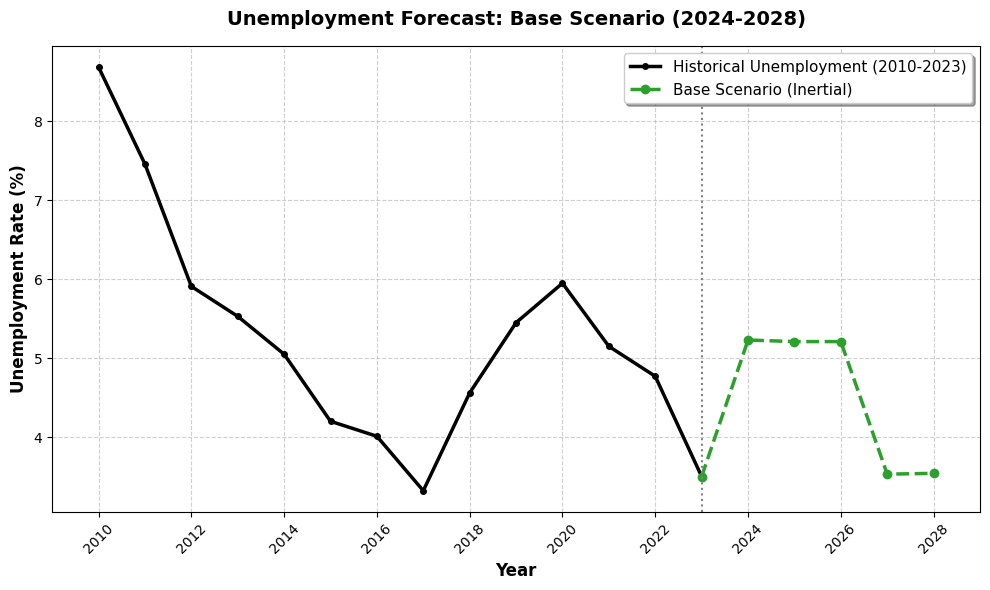

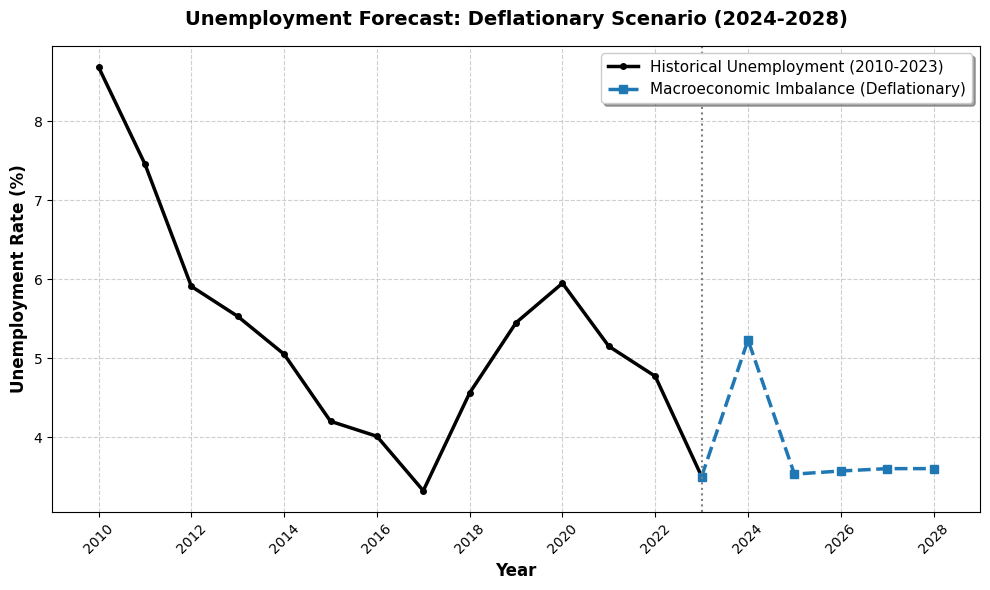

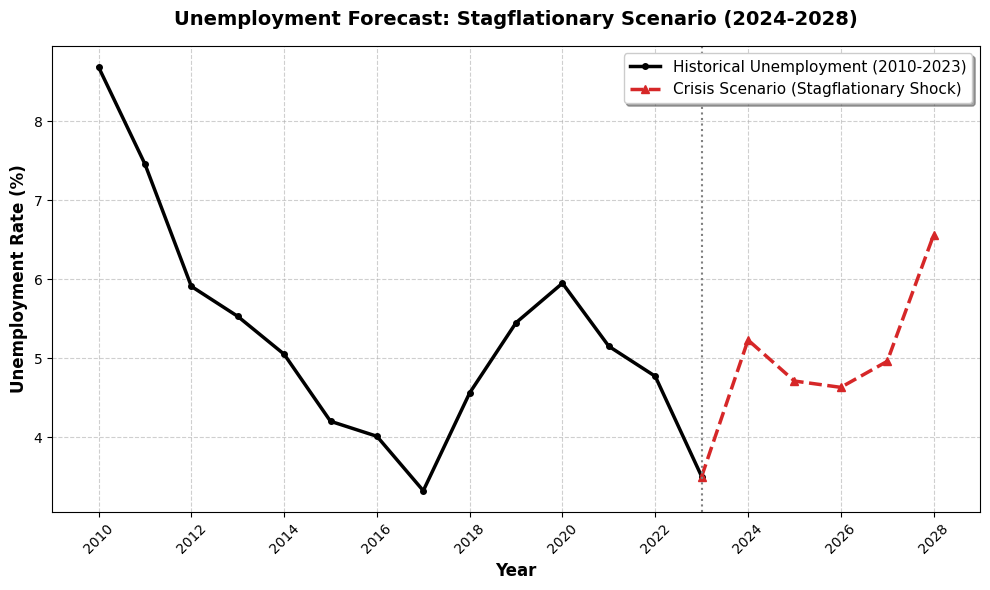

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings("ignore")

# 1. ACTUAL HISTORICAL DATA (2010-2023)
years_historical = np.arange(2010, 2024)
unemployment_historical = [8.69, 7.46, 5.91, 5.53, 5.05, 4.2, 4.01, 3.32,
                           4.56, 5.45, 5.95, 5.15, 4.77, 3.5]

# 2. GradientBoosting FORECASTS (2024-2028)
years_forecast = np.arange(2024, 2029)

y_pred_base = [5.23,  5.21,  5.21,  3.53, 3.54]   # Inertial Scenario (Base)
y_pred_opti = [5.23,  3.53,  3.57,  3.60,  3.60]   # Deflationary Shock (Opti)
y_pred_pessi = [5.23, 4.71, 4.63, 4.96,  6.56]   # Stagflationary Shock (Pessi)

# 3. DATA PREPARATION FOR SEAMLESS GRAPH
last_historical_year = years_historical[-1]
last_historical_value = unemployment_historical[-1]

# Join 2023 data with forecasts so the line connects cleanly
years_plot = np.insert(years_forecast, 0, last_historical_year)
y_base_plot = np.insert(y_pred_base, 0, last_historical_value)
y_opti_plot = np.insert(y_pred_opti, 0, last_historical_value)
y_pessi_plot = np.insert(y_pred_pessi, 0, last_historical_value)

# 4. MASTER PLOTTING FUNCTION
def create_forecast_plot(y_forecast_data, line_color, line_label, line_marker, plot_title, file_name):
    """Generates and saves a standardized forecast plot."""
    plt.figure(figsize=(10, 6))

    # Historical line (Constant across all plots)
    plt.plot(years_historical, unemployment_historical, color='black', linewidth=2.5,
             label='Historical Unemployment (2010-2023)', marker='o', markersize=4)

    # Forecast line (Dynamic)
    plt.plot(years_plot, y_forecast_data, color=line_color, linewidth=2.5, linestyle='--',
             label=line_label, marker=line_marker, markersize=6)

    # Formatting
    plt.title(plot_title, fontsize=14, fontweight='bold', pad=15)
    plt.xlabel('Year', fontsize=12, fontweight='bold')
    plt.ylabel('Unemployment Rate (%)', fontsize=12, fontweight='bold')

    # Forecast horizon vertical divider
    plt.axvline(x=2023, color='gray', linestyle=':', linewidth=1.5)

    # Dynamically place the text so it doesn't overlap the lines
    max_y_val = max(max(unemployment_historical), max(y_forecast_data))
    plt.text(2023.2, max_y_val * 0.95, 'Forecast Horizon \n(2024-2028)', color='gray', fontsize=10, fontweight='bold')

    # Axes and Grid
    plt.xlim(2009, 2029)
    plt.xticks(np.arange(2010, 2029, 2), rotation=45)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(loc='upper right', fontsize=11, frameon=True, shadow=True)

    # Clean UI and Save
    plt.tight_layout()
    plt.savefig(file_name, dpi=300)
    plt.show()

# 5. GENERATE THE 3 SEPARATE PLOTS

# Chart 1: Base Scenario
create_forecast_plot(
    y_forecast_data=y_base_plot,
    line_color='#2ca02c',  # Professional Green
    line_label='Base Scenario (Inertial)',
    line_marker='o',
    plot_title='Unemployment Forecast: Base Scenario (2024-2028)',
    file_name='forecast_base.png'
)

# Chart 2: Deflationary Scenario
create_forecast_plot(
    y_forecast_data=y_opti_plot,
    line_color='#1f77b4',  # Professional Blue
    line_label='Macroeconomic Imbalance (Deflationary)',
    line_marker='s', # Square marker
    plot_title='Unemployment Forecast: Deflationary Scenario (2024-2028)',
    file_name='forecast_deflationary.png'
)

# Chart 3: Stagflationary Scenario
create_forecast_plot(
    y_forecast_data=y_pessi_plot,
    line_color='#d62728',  # Professional Red
    line_label='Crisis Scenario (Stagflationary Shock)',
    line_marker='^', # Triangle marker
    plot_title='Unemployment Forecast: Stagflationary Scenario (2024-2028)',
    file_name='forecast_stagflationary.png'
)

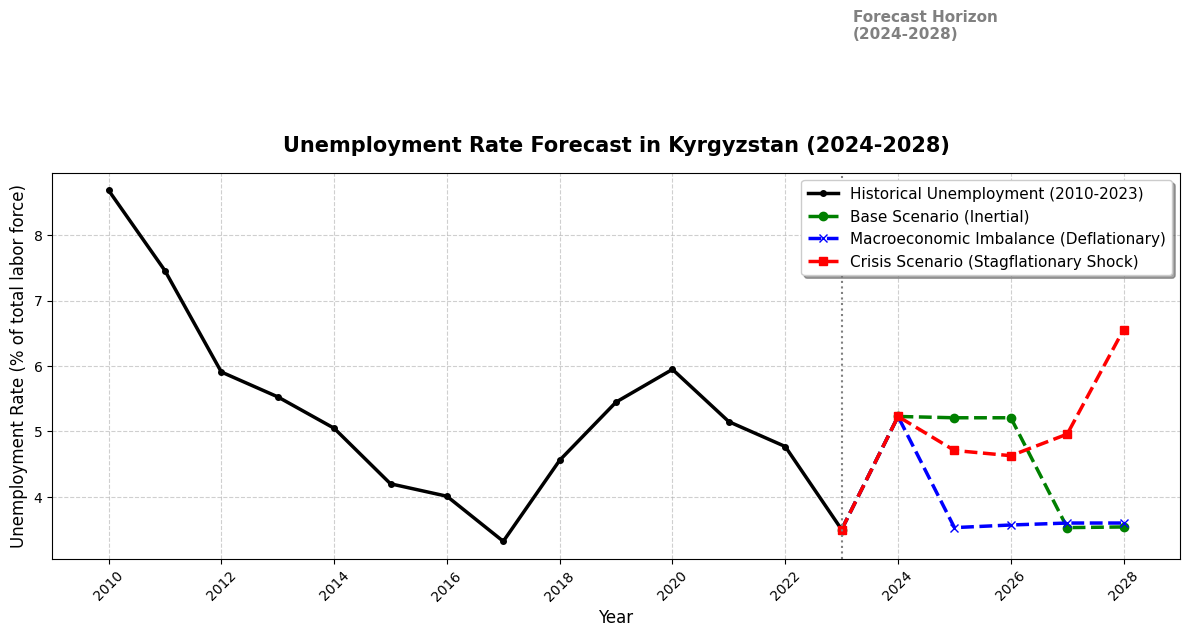

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings("ignore")

# 1. ACTUAL HISTORICAL DATA (2000-2023)
# 24 historical data points
years_historical = np.arange(2010, 2024)
unemployment_historical = [8.69, 7.46, 5.91, 5.53, 5.05, 4.2, 4.01, 3.32,
                           4.56, 5.45, 5.95, 5.15, 4.77, 3.5]

# 2. GradientBoosting FORECASTS (2024-2028)
# 5 forecast points
years_forecast = np.arange(2024, 2029)

y_pred_base = [5.23,  5.21,  5.21,  3.53, 3.54]   # Inertial Scenario (Base)
y_pred_opti = [5.23,  3.53,  3.57,  3.60,  3.60]   # Deflationary Shock (Opti)
y_pred_pessi = [5.23, 4.71, 4.63, 4.96,  6.56]   # Stagflationary Shock (Pessi)

# 3. DATA PREPARATION FOR SEAMLESS GRAPH
last_historical_year = years_historical[-1]
last_historical_value = unemployment_historical[-1]

# Join 2023 data with forecasts
years_plot = np.insert(years_forecast, 0, last_historical_year)
y_base_plot = np.insert(y_pred_base, 0, last_historical_value)
y_opti_plot = np.insert(y_pred_opti, 0, last_historical_value)
y_pessi_plot = np.insert(y_pred_pessi, 0, last_historical_value)

# 4. PLOT CONSTRUCTION
plt.figure(figsize=(12, 7))

# Historical line
plt.plot(years_historical, unemployment_historical, color='black', linewidth=2.5,
         label='Historical Unemployment (2010-2023)', marker='o', markersize=4)

# Forecast lines
plt.plot(years_plot, y_base_plot, color='green', linewidth=2.5, linestyle='--',
         label='Base Scenario (Inertial)', marker='o')

plt.plot(years_plot, y_opti_plot, color='blue', linewidth=2.5, linestyle='--',
         label='Macroeconomic Imbalance (Deflationary)', marker='x')

plt.plot(years_plot, y_pessi_plot, color='red', linewidth=2.5, linestyle='--',
         label='Crisis Scenario (Stagflationary Shock)', marker='s')

# Formatting
plt.title('Unemployment Rate Forecast in Kyrgyzstan (2024-2028)',
          fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Unemployment Rate (% of total labor force)', fontsize=12)

# Forecast horizon vertical divider
plt.axvline(x=2023, color='gray', linestyle=':', linewidth=1.5)
plt.text(2023.2, 11, 'Forecast Horizon \n(2024-2028)', color='gray', fontsize=11, fontweight='bold')

plt.xlim(2009, 2029)
plt.xticks(np.arange(2010, 2029, 2), rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper right', fontsize=11, frameon=True, shadow=True)

plt.tight_layout()
plt.savefig('final_unemployment_forecast.png', dpi=300)
plt.show()